# CWE 32k — Entropy Analysis: Baseline vs Controller

**Runs:**
- Baseline: `baseline_no_session_prefixON_32k_cwefwe` — `calibrated_scalar`, `session_size=100k`, `temp_gain=0.0` (fixed temp)
- Controller: `50session_3cali_prefixON_0p7ema_32k_cwe_maxtemp1` — `calibrated_per_head`, `session_size=50`, `temp_gain=0.15`, `target_trim_ratio=0.1`

**Analyses:**
1. Entropy distribution — success vs fail (both runs)
2. Entropy tracking error (`entropy_mean − target`) over steps
3. Matched-example comparison — groups by who got it right

In [28]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

ROOT = Path("/c2/jenny/r3/RULER_outputs/llama3.1-8b-chat/synthetic/32768/data_session_runs/cwe")
BASE_TAG = "baseline_no_session_prefixON_32k_cwefwe"
CTRL_TAG = "50session_3cali_prefixON_0p7ema_32k_cwe_maxtemp1"

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(l) for l in f if l.strip()]

base_preds = load_jsonl(ROOT / f"cwe_entropy_attn_predictions_{BASE_TAG}")
ctrl_preds = load_jsonl(ROOT / f"cwe_entropy_attn_predictions_{CTRL_TAG}")
base_elog  = load_jsonl(ROOT / f"cwe_entropy_attn_entropy_log_{BASE_TAG}")
ctrl_elog  = load_jsonl(ROOT / f"cwe_entropy_attn_entropy_log_{CTRL_TAG}")

def max_steps(elog):
    return max(s["step"] for ex in elog for s in ex["entropy_log"]) + 1

BASE_STEPS = max_steps(base_elog)
CTRL_STEPS = max_steps(ctrl_elog)
N_STEPS = min(BASE_STEPS, CTRL_STEPS)
steps = np.arange(N_STEPS)
print(f"Base max step: {BASE_STEPS-1}  Ctrl max step: {CTRL_STEPS-1}  → comparing first {N_STEPS} steps")

def to_arrays(elog, n_steps):
    N = len(elog)
    H   = np.full((N, n_steps), np.nan, dtype=np.float32)
    Std = np.full((N, n_steps), np.nan, dtype=np.float32)
    T   = np.full((N, n_steps), np.nan, dtype=np.float32)
    KV  = np.full((N, n_steps), np.nan, dtype=np.float32)  # kv_len
    tgt = np.zeros(N, dtype=np.float32)
    for i, ex in enumerate(elog):
        tgt[i] = ex["prompt_target_mean"]
        for s in ex["entropy_log"]:
            st = s["step"]
            if st < n_steps:
                H[i, st]   = s["entropy_mean"]
                Std[i, st] = s["entropy_std"]
                T[i, st]   = s["temp_mean"]
                KV[i, st]  = s["kv_len"]
    return H, Std, T, KV, tgt

base_H, base_S, base_T, base_KV, base_tgt = to_arrays(base_elog, N_STEPS)
ctrl_H, ctrl_S, ctrl_T, ctrl_KV, ctrl_tgt = to_arrays(ctrl_elog, N_STEPS)

# Normalized entropy: H / log(kv_len)  — same quantity as MRCR attn_entropy_trace
base_Hn = base_H / np.log(np.where(np.isnan(base_KV), np.nan, base_KV))
ctrl_Hn = ctrl_H / np.log(np.where(np.isnan(ctrl_KV), np.nan, ctrl_KV))

# _ruler_all_hit: fraction of 10 target words found per example (primary CWE metric)
base_score = np.array([p["_ruler_all_hit"] for p in base_preds], dtype=np.float32)
ctrl_score = np.array([p["_ruler_all_hit"] for p in ctrl_preds], dtype=np.float32)

base_hit = base_score > 0
ctrl_hit = ctrl_score > 0

ctrl_only = ctrl_hit & ~base_hit
both_hit  = ctrl_hit &  base_hit
both_miss = ~ctrl_hit & ~base_hit
base_only = base_hit & ~ctrl_hit

print(f"\nBaseline  ruler_all_acc: {base_score.mean()*100:.2f}%  (any-word hit: {base_hit.sum()}/500)")
print(f"Controller ruler_all_acc: {ctrl_score.mean()*100:.2f}%  (any-word hit: {ctrl_hit.sum()}/500)")
print(f"\nMatched groups:")
print(f"  ctrl-only hit: {ctrl_only.sum()}  |  both hit: {both_hit.sum()}  "
      f"|  both miss: {both_miss.sum()}  |  base-only hit: {base_only.sum()}")

Base max step: 47  Ctrl max step: 62  → comparing first 48 steps

Baseline  ruler_all_acc: 0.70%  (any-word hit: 15/500)
Controller ruler_all_acc: 27.14%  (any-word hit: 327/500)

Matched groups:
  ctrl-only hit: 312  |  both hit: 15  |  both miss: 173  |  base-only hit: 0


## Score distribution (`_ruler_all_hit`)

`ruler_all_acc` = mean of per-example scores × 100, where each score = fraction of 10 target words found.
No example achieves score 1.0 (all 10 words), so hits are always partial. The binary hit/miss split (`score > 0`) is used in Analyses 1–2; Analysis 10 also shows mean score per matched group.

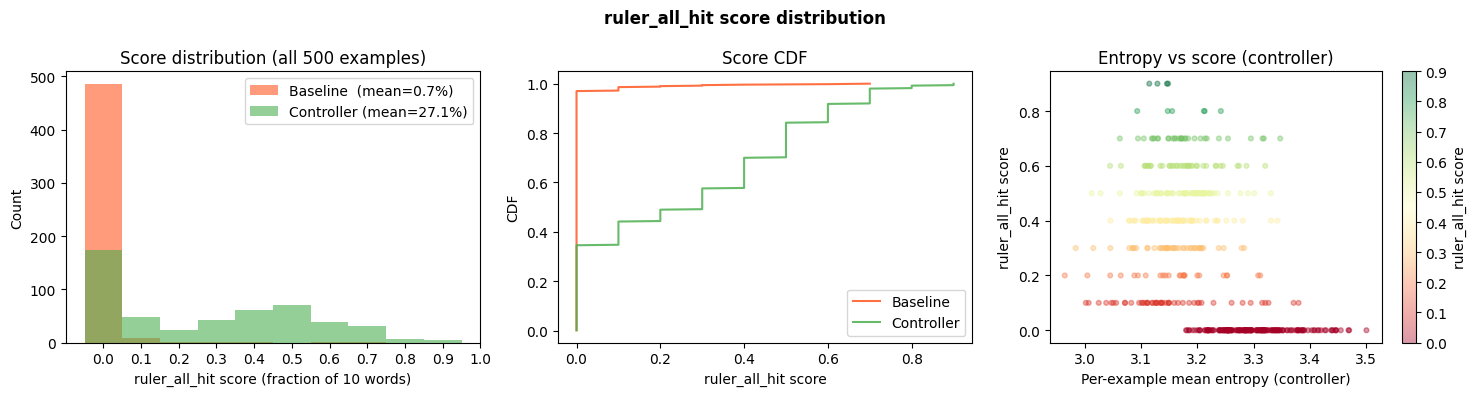

Score distribution (count per level):
  0.0: baseline= 485  ctrl= 173
  0.1: baseline=   8  ctrl=  48
  0.2: baseline=   2  ctrl=  24
  0.3: baseline=   2  ctrl=  43
  0.4: baseline=   1  ctrl=  62
  0.5: baseline=   0  ctrl=  71
  0.6: baseline=   1  ctrl=  38
  0.7: baseline=   1  ctrl=  31
  0.8: baseline=   0  ctrl=   6
  0.9: baseline=   0  ctrl=   4


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("ruler_all_hit score distribution", fontsize=12, fontweight="bold")

score_bins = np.arange(0, 1.05, 0.1) - 0.05  # centered bins

# -- histogram: baseline vs controller --
ax = axes[0]
ax.hist(base_score, bins=score_bins, alpha=0.6, color="#FF5722", density=False,
        label=f"Baseline  (mean={base_score.mean()*100:.1f}%)")
ax.hist(ctrl_score, bins=score_bins, alpha=0.6, color="#4CAF50", density=False,
        label=f"Controller (mean={ctrl_score.mean()*100:.1f}%)")
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_xlabel("ruler_all_hit score (fraction of 10 words)")
ax.set_ylabel("Count")
ax.set_title("Score distribution (all 500 examples)")
ax.legend()

# -- score CDF --
ax = axes[1]
for scores, lbl, col in [(base_score, "Baseline",   "#FF5722"),
                          (ctrl_score, "Controller", "#4CAF50")]:
    sorted_s = np.sort(scores)
    cdf = np.arange(1, len(sorted_s)+1) / len(sorted_s)
    ax.plot(sorted_s, cdf, color=col, label=lbl, alpha=0.85)
ax.set_xlabel("ruler_all_hit score")
ax.set_ylabel("CDF")
ax.set_title("Score CDF")
ax.legend()

# -- score vs mean entropy scatter (controller) --
ax = axes[2]
ctrl_H_mean = np.nanmean(ctrl_H, axis=1)
sc = ax.scatter(ctrl_H_mean, ctrl_score, c=ctrl_score, cmap="RdYlGn",
                alpha=0.4, s=12, vmin=0, vmax=0.9)
plt.colorbar(sc, ax=ax, label="ruler_all_hit score")
ax.set_xlabel("Per-example mean entropy (controller)")
ax.set_ylabel("ruler_all_hit score")
ax.set_title("Entropy vs score (controller)")

fig.tight_layout()
plt.show()

# Score breakdown by bin
print("Score distribution (count per level):")
for v in np.arange(0, 1.0, 0.1):
    b_count = np.sum(np.isclose(base_score, round(v, 1), atol=0.05))
    c_count = np.sum(np.isclose(ctrl_score, round(v, 1), atol=0.05))
    print(f"  {v:.1f}: baseline={b_count:4d}  ctrl={c_count:4d}")

## Analysis 1 — Entropy distribution: success vs fail

Three views for each run:
- **Left**: histogram of per-example mean entropy (averaged over all 40 generation steps)
- **Middle**: mean entropy trajectory ± 1 std across examples
- **Right**: entropy_std trajectory — measures head disagreement at each step

/tmp/ipykernel_2202411/443388646.py:46: RuntimeWarning: Mean of empty slice
  m = np.nanmean(Hn[mask], axis=0)
/tmp/ipykernel_2202411/443388646.py:60: RuntimeWarning: Mean of empty slice
  m = np.nanmean(Std[mask], axis=0)


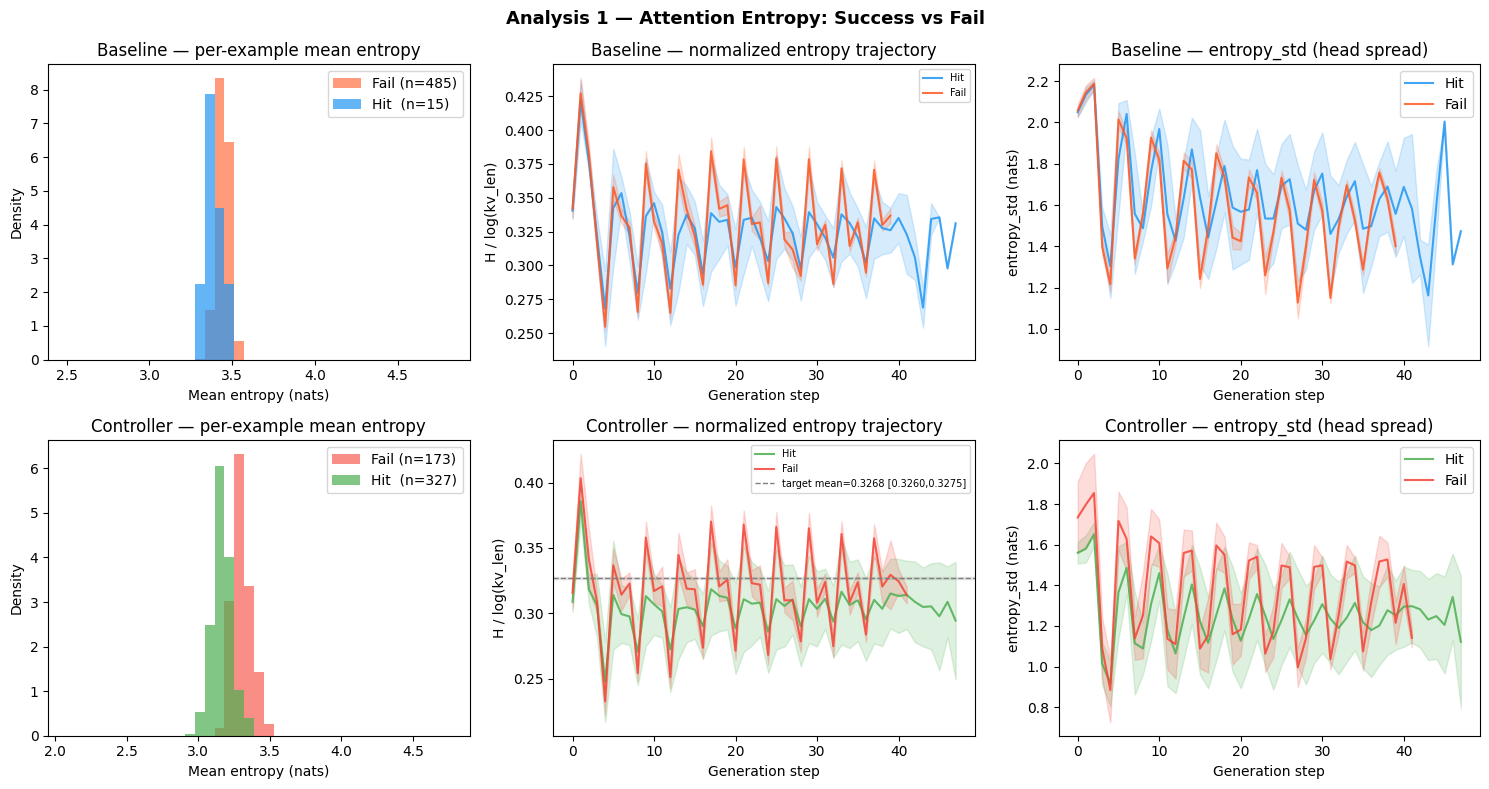

In [30]:
C = dict(
    base_hit="#2196F3", base_miss="#FF5722",
    ctrl_hit="#4CAF50", ctrl_miss="#F44336",
)
BAND = 0.18

def draw_target_band(ax, tgt, orient="h"):
    """Shaded band spanning per-session target range + mean line."""
    lo, hi, mn = float(tgt.min()), float(tgt.max()), float(tgt.mean())
    if orient == "h":
        ax.axhspan(lo, hi, color="gray", alpha=0.15, zorder=0)
        ax.axhline(mn, color="gray", ls="--", lw=1,
                   label=f"target mean={mn:.4f} [{lo:.4f},{hi:.4f}]")
    else:
        ax.axvspan(lo, hi, color="gray", alpha=0.15, zorder=0)
        ax.axvline(mn, color="gray", ls="--", lw=1,
                   label=f"target mean={mn:.4f} [{lo:.4f},{hi:.4f}]")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Analysis 1 — Attention Entropy: Success vs Fail", fontsize=13, fontweight="bold")

# show_target only for controller — baseline has no target it acts on
rows = [
    ("Baseline",   base_H,  base_Hn, base_S, base_tgt, base_hit, C["base_hit"],  C["base_miss"], False),
    ("Controller", ctrl_H,  ctrl_Hn, ctrl_S, ctrl_tgt, ctrl_hit, C["ctrl_hit"],  C["ctrl_miss"], True),
]

for row_i, (label, H, Hn, Std, tgt, hit, c_hit, c_miss, show_target) in enumerate(rows):
    n_hit, n_miss = hit.sum(), (~hit).sum()

    # -- histogram of per-example mean entropy (raw nats) --
    ax = axes[row_i, 0]
    hit_means  = np.nanmean(H[hit],  axis=1)
    miss_means = np.nanmean(H[~hit], axis=1)
    bins = np.linspace(np.nanmin(H), np.nanmax(H), 40)
    ax.hist(miss_means, bins=bins, alpha=0.6, color=c_miss, density=True, label=f"Fail (n={n_miss})")
    ax.hist(hit_means,  bins=bins, alpha=0.7, color=c_hit,  density=True, label=f"Hit  (n={n_hit})")
    ax.set_title(f"{label} — per-example mean entropy")
    ax.set_xlabel("Mean entropy (nats)")
    ax.set_ylabel("Density")
    ax.legend()

    # -- normalized entropy trajectory --
    ax = axes[row_i, 1]
    for mask, lbl, col in [(hit, "Hit", c_hit), (~hit, "Fail", c_miss)]:
        m = np.nanmean(Hn[mask], axis=0)
        s = np.nanstd(Hn[mask],  axis=0)
        ax.plot(steps, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    if show_target:
        draw_target_band(ax, tgt, orient="h")
    ax.set_title(f"{label} — normalized entropy trajectory")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("H / log(kv_len)")
    ax.legend(fontsize=7)

    # -- entropy_std trajectory (head spread, raw nats) --
    ax = axes[row_i, 2]
    for mask, lbl, col in [(hit, "Hit", c_hit), (~hit, "Fail", c_miss)]:
        m = np.nanmean(Std[mask], axis=0)
        s = np.nanstd(Std[mask],  axis=0)
        ax.plot(steps, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    ax.set_title(f"{label} — entropy_std (head spread)")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("entropy_std (nats)")
    ax.legend()

fig.tight_layout()
plt.show()

### Analysis 1b — Entropy distribution: score groups (miss / partial / good)

Uses `ruler_all_hit` score instead of binary hit/miss to reflect `ruler_all_acc`:
- **miss**: score = 0 (no word found)
- **partial**: 0 < score < 0.5 (fewer than half of 10 words)
- **good**: score ≥ 0.5 (half or more of 10 words found)

Finer than 1a: reveals whether the entropy gap scales with how *many* words were retrieved.

/tmp/ipykernel_2202411/2375611067.py:45: RuntimeWarning: Mean of empty slice
  m = np.nanmean(Hn[mask], axis=0)
/tmp/ipykernel_2202411/2375611067.py:60: RuntimeWarning: Mean of empty slice
  m = np.nanmean(Std[mask], axis=0)


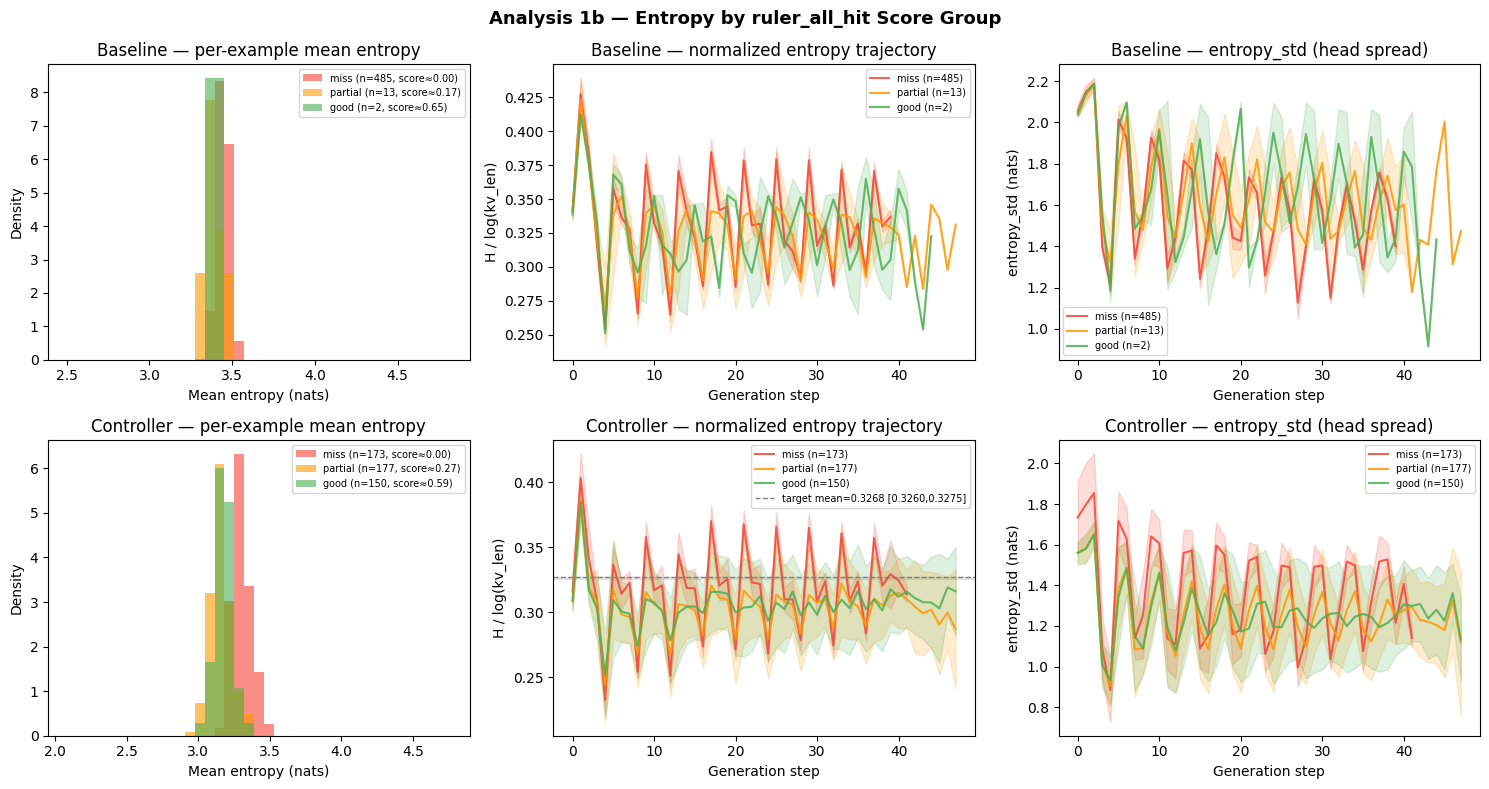

Score group summary:
  run+group                  n  score_mean    H_mean   Hn_mean
  ----------------------------------------------------------
  Baseline miss            485      0.0000    3.4457    0.3316
  Baseline partial          13      0.1692    3.3914    0.3264
  Baseline good              2      0.6500    3.3952    0.3268
  Controller miss          173      0.0000    3.3041    0.3180
  Controller partial       177      0.2672    3.1563    0.3038
  Controller good          150      0.5893    3.1768    0.3057


In [31]:
SG = {"miss": "#F44336", "partial": "#FF9800", "good": "#4CAF50"}

def score_groups(score):
    miss    = score == 0
    partial = (score > 0) & (score < 0.5)
    good    = score >= 0.5
    return miss, partial, good

base_miss_g, base_partial_g, base_good_g = score_groups(base_score)
ctrl_miss_g, ctrl_partial_g, ctrl_good_g = score_groups(ctrl_score)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Analysis 1b — Entropy by ruler_all_hit Score Group", fontsize=13, fontweight="bold")

rows_1b = [
    ("Baseline",   base_H, base_Hn, base_S, base_tgt,
     base_miss_g, base_partial_g, base_good_g, base_score, False),
    ("Controller", ctrl_H, ctrl_Hn, ctrl_S, ctrl_tgt,
     ctrl_miss_g, ctrl_partial_g, ctrl_good_g, ctrl_score, True),
]

for row_i, (label, H, Hn, Std, tgt, miss_g, partial_g, good_g, score, show_target) in enumerate(rows_1b):
    sg_masks = [
        (miss_g,    "miss",    SG["miss"]),
        (partial_g, "partial", SG["partial"]),
        (good_g,    "good",    SG["good"]),
    ]

    # -- per-example mean entropy histogram --
    ax = axes[row_i, 0]
    bins = np.linspace(np.nanmin(H), np.nanmax(H), 40)
    for mask, lbl, col in sg_masks:
        if mask.sum() == 0: continue
        ax.hist(np.nanmean(H[mask], axis=1), bins=bins, alpha=0.6, color=col,
                density=True, label=f"{lbl} (n={mask.sum()}, score≈{score[mask].mean():.2f})")
    ax.set_title(f"{label} — per-example mean entropy")
    ax.set_xlabel("Mean entropy (nats)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

    # -- normalized entropy trajectory --
    ax = axes[row_i, 1]
    for mask, lbl, col in sg_masks:
        if mask.sum() == 0: continue
        m = np.nanmean(Hn[mask], axis=0)
        s = np.nanstd(Hn[mask],  axis=0)
        ax.plot(steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    if show_target:
        draw_target_band(ax, tgt, orient="h")
    ax.set_title(f"{label} — normalized entropy trajectory")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("H / log(kv_len)")
    ax.legend(fontsize=7)

    # -- entropy_std trajectory --
    ax = axes[row_i, 2]
    for mask, lbl, col in sg_masks:
        if mask.sum() == 0: continue
        m = np.nanmean(Std[mask], axis=0)
        s = np.nanstd(Std[mask],  axis=0)
        ax.plot(steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    ax.set_title(f"{label} — entropy_std (head spread)")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("entropy_std (nats)")
    ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

print("Score group summary:")
print(f"  {'run+group':<22} {'n':>5}  {'score_mean':>10}  {'H_mean':>8}  {'Hn_mean':>8}")
print("  " + "-" * 58)
for label, H, Hn, _, _, miss_g, partial_g, good_g, score, _ in rows_1b:
    for mask, lbl, _ in [(miss_g, "miss", None), (partial_g, "partial", None), (good_g, "good", None)]:
        if mask.sum() == 0: continue
        print(f"  {(label+' '+lbl):<22} {mask.sum():>5}  "
              f"{score[mask].mean():>10.4f}  {np.nanmean(H[mask]):>8.4f}  {np.nanmean(Hn[mask]):>8.4f}")

## Analysis 2 — Controller tracking error + baseline reference

- **Col 0**: histogram of per-example mean controller tracking error
- **Col 1**: controller signed error trajectory `H/log(kv_len) − target`
- **Col 2**: baseline normalized entropy trajectory (hit vs fail) — reference for what uncontrolled entropy looks like

Baseline is shown in col 2 for comparison only, not as a tracking error.

**Hit definitions:**
- CWE: `ruler_all_hit > 0` (any of 10 words found)
- FWE: `ruler_all_hit == 1.0` (all 3 words found)

*(FWE loading cell must be executed before this cell runs)*

/tmp/ipykernel_2202411/2878314011.py:62: RuntimeWarning: Mean of empty slice
  m = np.nanmean(err[mask], axis=0)
/tmp/ipykernel_2202411/2878314011.py:75: RuntimeWarning: Mean of empty slice
  m = np.nanmean(bHn[mask], axis=0)


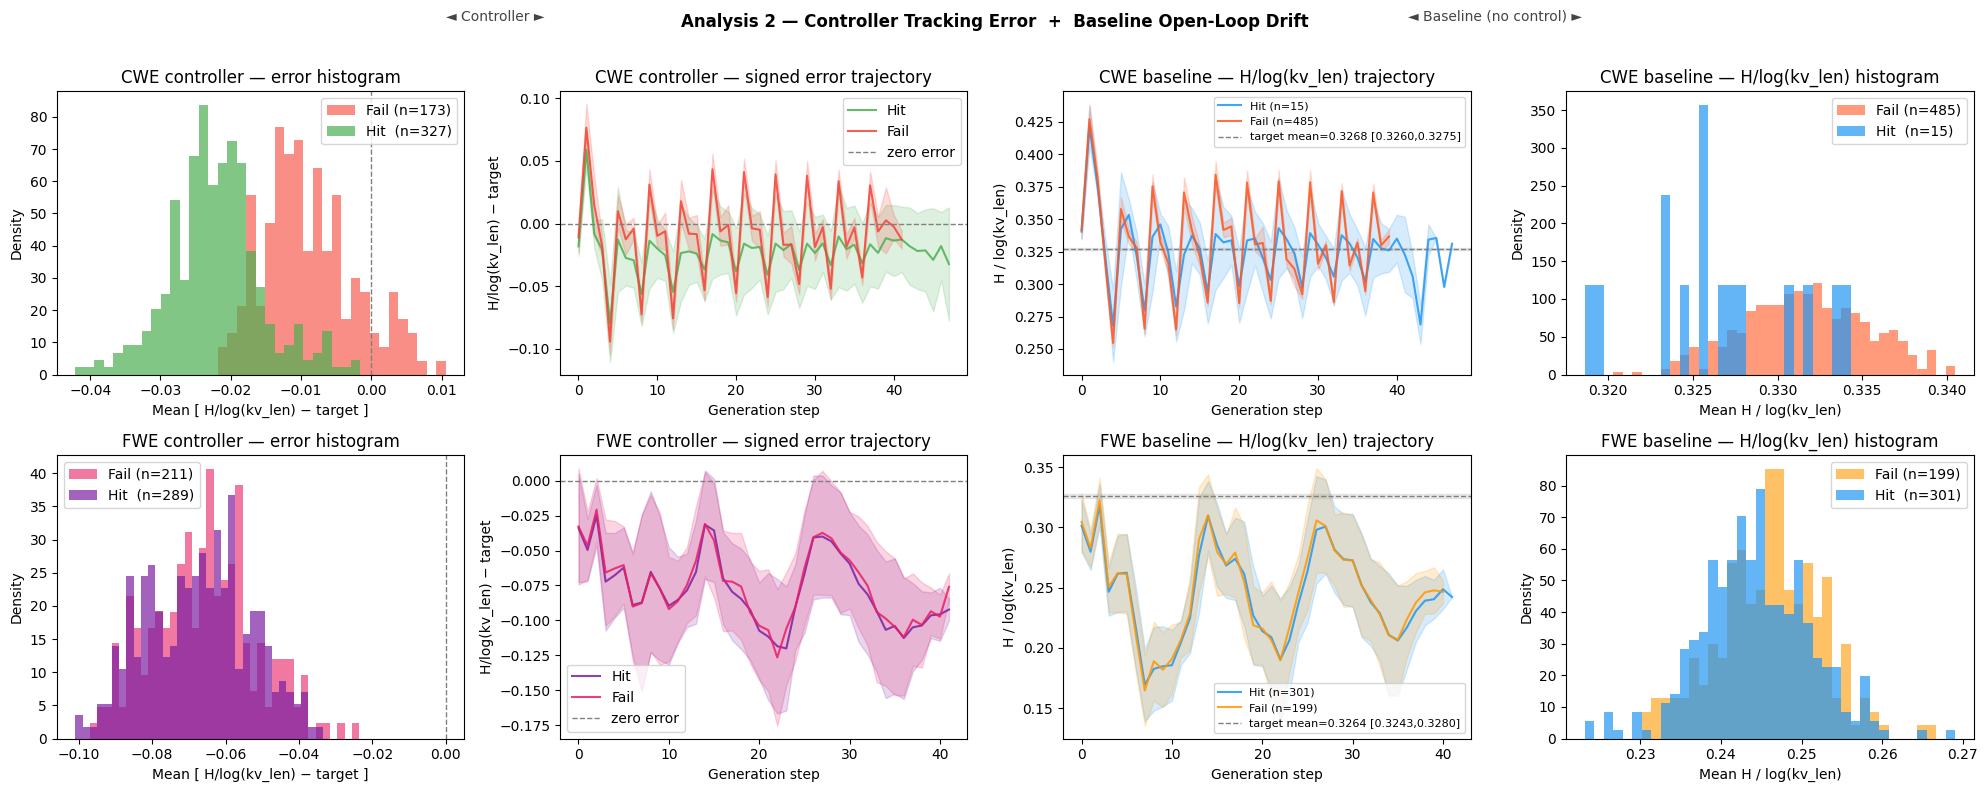

Controller tracking error  [ H/log(kv_len) − target ]:
  CWE  hit:  mean=-0.02215   miss: mean=-0.00884
  FWE  hit:  mean=-0.07136   miss: mean=-0.06978

Baseline normalized entropy  [ H/log(kv_len) ]:
  CWE  hit:  mean=0.32649   miss: mean=0.33162
  FWE  hit:  mean=0.24420   miss: mean=0.24609


In [40]:
# Controller tracking error: H/log(kv_len) − prompt_target_mean
# Baseline open-loop drift: same formula, but baseline never acts on it
ctrl_err = ctrl_Hn - ctrl_tgt[:, None]
base_err = base_Hn - base_tgt[:, None]   # kept for Analysis 10

task_rows = [
    ("CWE",
     ctrl_err, ctrl_tgt, ctrl_hit,  ~ctrl_hit,
     C["ctrl_hit"], C["ctrl_miss"], steps,
     base_Hn,  base_err, base_hit,  ~base_hit,
     C["base_hit"], C["base_miss"]),
]

_fwe_loaded = "fwe_cHn" in dir()
if _fwe_loaded:
    fwe_ctrl_err = fwe_cHn - fwe_ctgt[:, None]
    fwe_base_err = fwe_bHn - fwe_btgt[:, None]
    fwe_hit_full = fwe_cs == 1.0
    fwe_base_hit = fwe_bs == 1.0
    task_rows.append((
        "FWE",
        fwe_ctrl_err, fwe_ctgt, fwe_hit_full, ~fwe_hit_full,
        "#7B1FA2",    "#E91E63", fwe_steps,
        fwe_bHn, fwe_base_err, fwe_base_hit, ~fwe_base_hit,
        "#2196F3",    "#FF9800",
    ))
else:
    print("\u26a0  FWE not loaded \u2014 only CWE row shown. Run the FWE loading cell (69e1ec41) first.")

n_rows = len(task_rows)
fig, axes = plt.subplots(n_rows, 4, figsize=(20,  4 * n_rows))
if n_rows == 1:
    axes = axes[None, :]
fig.suptitle("Analysis 2 \u2014 Controller Tracking Error  +  Baseline Open-Loop Drift",
             fontsize=12, fontweight="bold")
fig.text(0.25, 0.97, "\u25c4 Controller \u25ba", ha="center", fontsize=10, color="#444")
fig.text(0.75, 0.97, "\u25c4 Baseline (no control) \u25ba", ha="center", fontsize=10, color="#444")

for row_i, (label,
            err,  tgt,  hit,  miss,  c_hit,  c_miss, st,
            bHn,  berr, b_hit, b_miss, c_b_hit, c_b_miss) in enumerate(task_rows):

    # -- Col 0: controller error histogram --
    ax = axes[row_i, 0]
    per_ex_hit  = np.nanmean(err[hit],  axis=1)
    per_ex_miss = np.nanmean(err[miss], axis=1)
    all_vals = np.concatenate([per_ex_hit, per_ex_miss])
    bins = np.linspace(all_vals.min(), all_vals.max(), 40)
    ax.hist(per_ex_miss, bins=bins, alpha=0.6, color=c_miss, density=True,
            label=f"Fail (n={miss.sum()})")
    ax.hist(per_ex_hit,  bins=bins, alpha=0.7, color=c_hit,  density=True,
            label=f"Hit  (n={hit.sum()})")
    ax.axvline(0, color="gray", ls="--", lw=1)
    ax.set_title(f"{label} controller \u2014 error histogram")
    ax.set_xlabel("Mean [ H/log(kv_len) \u2212 target ]")
    ax.set_ylabel("Density")
    ax.legend()

    # -- Col 1: controller signed error trajectory --
    ax = axes[row_i, 1]
    for mask, lbl, col in [(hit, "Hit", c_hit), (miss, "Fail", c_miss)]:
        m = np.nanmean(err[mask], axis=0)
        s = np.nanstd(err[mask],  axis=0)
        ax.plot(st, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(st, m-s, m+s, color=col, alpha=BAND)
    ax.axhline(0, color="gray", ls="--", lw=1, label="zero error")
    ax.set_title(f"{label} controller \u2014 signed error trajectory")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("H/log(kv_len) \u2212 target")
    ax.legend()

    # -- Col 2: baseline H/log(kv_len) trajectory --
    ax = axes[row_i, 2]
    for mask, lbl, col in [(b_hit, "Hit", c_b_hit), (b_miss, "Fail", c_b_miss)]:
        m = np.nanmean(bHn[mask], axis=0)
        s = np.nanstd(bHn[mask],  axis=0)
        ax.plot(st, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
        ax.fill_between(st, m-s, m+s, color=col, alpha=BAND)
    draw_target_band(ax, tgt, orient="h")
    ax.set_title(f"{label} baseline \u2014 H/log(kv_len) trajectory")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("H / log(kv_len)")
    ax.legend(fontsize=8)

    # -- Col 3: baseline normalized entropy histogram --
    ax = axes[row_i, 3]
    per_ex_b_hit  = np.nanmean(bHn[b_hit],  axis=1)
    per_ex_b_miss = np.nanmean(bHn[b_miss], axis=1)
    all_b = np.concatenate([per_ex_b_hit, per_ex_b_miss])
    bins_b = np.linspace(all_b.min(), all_b.max(), 40)
    ax.hist(per_ex_b_miss, bins=bins_b, alpha=0.6, color=c_b_miss, density=True,
            label=f"Fail (n={b_miss.sum()})")
    ax.hist(per_ex_b_hit,  bins=bins_b, alpha=0.7, color=c_b_hit,  density=True,
            label=f"Hit  (n={b_hit.sum()})")
    ax.set_title(f"{label} baseline \u2014 H/log(kv_len) histogram")
    ax.set_xlabel("Mean H / log(kv_len)")
    ax.set_ylabel("Density")
    ax.legend()

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("Controller tracking error  [ H/log(kv_len) \u2212 target ]:")
for label, err, tgt, hit, miss, *_ in task_rows:
    print(f"  {label}  hit:  mean={np.nanmean(err[hit]):+.5f}   "
          f"miss: mean={np.nanmean(err[miss]):+.5f}")
print("\nBaseline normalized entropy  [ H/log(kv_len) ]:")
for label, _, tgt, _, _, _, _, _, bHn, _, b_hit, b_miss, *_ in task_rows:
    print(f"  {label}  hit:  mean={np.nanmean(bHn[b_hit]):.5f}   "
          f"miss: mean={np.nanmean(bHn[b_miss]):.5f}")


### Analysis 2b — Tracking error by score group (miss / partial / good)

Same tracking error as Analysis 2 (`H/log(kv_len) − target`) but split by `ruler_all_hit` score group instead of binary hit/miss. Tests whether tighter tracking correlates with higher retrieval scores.

/tmp/ipykernel_2202411/1553558504.py:33: RuntimeWarning: Mean of empty slice
  m = np.nanmean(ctrl_err[mask], axis=0)
/tmp/ipykernel_2202411/1553558504.py:47: RuntimeWarning: Mean of empty slice
  m = np.nanmean(ctrl_T[mask], axis=0)


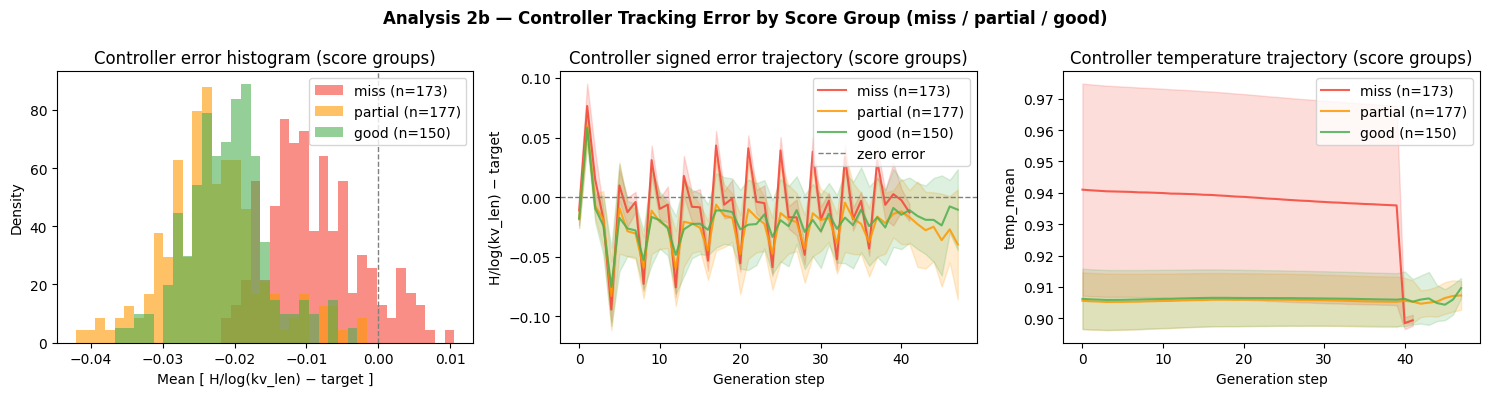

Tracking error by score group (controller):
  group                      n    err_mean     err_std    T_final_mean
  ------------------------------------------------------------------
  ctrl miss                173    -0.00884     0.03792         0.93599
  ctrl partial             177    -0.02311     0.03511         0.90525
  ctrl good                150    -0.02103     0.03487         0.90589


In [33]:
# ctrl_err / ctrl_T already defined in Analysis 2 cell above
# ctrl_miss_g / ctrl_partial_g / ctrl_good_g defined in Analysis 1b cell above

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Analysis 2b — Controller Tracking Error by Score Group (miss / partial / good)",
             fontsize=12, fontweight="bold")

sg_masks_ctrl = [
    (ctrl_miss_g,    "miss",    SG["miss"]),
    (ctrl_partial_g, "partial", SG["partial"]),
    (ctrl_good_g,    "good",    SG["good"]),
]

# -- per-example mean error histogram --
ax = axes[0]
all_vals = np.concatenate([np.nanmean(ctrl_err[mask], axis=1)
                            for mask, _, _ in sg_masks_ctrl if mask.sum() > 0])
bins = np.linspace(all_vals.min(), all_vals.max(), 40)
for mask, lbl, col in sg_masks_ctrl:
    if mask.sum() == 0: continue
    ax.hist(np.nanmean(ctrl_err[mask], axis=1), bins=bins, alpha=0.6, color=col,
            density=True, label=f"{lbl} (n={mask.sum()})")
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_title("Controller error histogram (score groups)")
ax.set_xlabel("Mean [ H/log(kv_len) − target ]")
ax.set_ylabel("Density")
ax.legend()

# -- signed error trajectory --
ax = axes[1]
for mask, lbl, col in sg_masks_ctrl:
    if mask.sum() == 0: continue
    m = np.nanmean(ctrl_err[mask], axis=0)
    s = np.nanstd(ctrl_err[mask],  axis=0)
    ax.plot(steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
    ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
ax.axhline(0, color="gray", ls="--", lw=1, label="zero error")
ax.set_title("Controller signed error trajectory (score groups)")
ax.set_xlabel("Generation step")
ax.set_ylabel("H/log(kv_len) − target")
ax.legend()

# -- temperature trajectory by score group --
ax = axes[2]
for mask, lbl, col in sg_masks_ctrl:
    if mask.sum() == 0: continue
    m = np.nanmean(ctrl_T[mask], axis=0)
    s = np.nanstd(ctrl_T[mask],  axis=0)
    ax.plot(steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
    ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
ax.set_title("Controller temperature trajectory (score groups)")
ax.set_xlabel("Generation step")
ax.set_ylabel("temp_mean")
ax.legend()

fig.tight_layout()
plt.show()

print("Tracking error by score group (controller):")
print(f"  {'group':<22} {'n':>5}  {'err_mean':>10}  {'err_std':>10}  {'T_final_mean':>14}")
print("  " + "-" * 66)
for mask, lbl, _ in sg_masks_ctrl:
    if mask.sum() == 0: continue
    flat = ctrl_err[mask].ravel()
    flat = flat[~np.isnan(flat)]
    T_row = ctrl_T[mask]
    T_fin = np.array([row[~np.isnan(row)][-1] if (~np.isnan(row)).any() else np.nan
                      for row in T_row])
    print(f"  {'ctrl '+lbl:<22} {mask.sum():>5}  "
          f"{flat.mean():>+10.5f}  {flat.std():>10.5f}  {np.nanmean(T_fin):>14.5f}")

## Analysis 2.5 — Normalized entropy (absolute level, not error)

Same structure as Analysis 2 but showing `H/log(kv_len)` directly — not subtracted from target. The target line is drawn as a reference so you can see where each group sits relative to it without the subtraction flattening the view.

- **Left**: per-example mean `H/log(kv_len)` distribution (hit vs fail), target marked as vertical line
- **Middle**: `H/log(kv_len)` trajectory ± 1σ, target as horizontal line
- **Right**: `entropy_std` (head spread, raw nats) — how much heads disagree per step

*(FWE loading cell must be executed before this cell runs)*

/tmp/ipykernel_2202411/1746160613.py:43: RuntimeWarning: Mean of empty slice
  m = np.nanmean(Hn[mask], axis=0)
/tmp/ipykernel_2202411/1746160613.py:56: RuntimeWarning: Mean of empty slice
  m = np.nanmean(Std[mask], axis=0)


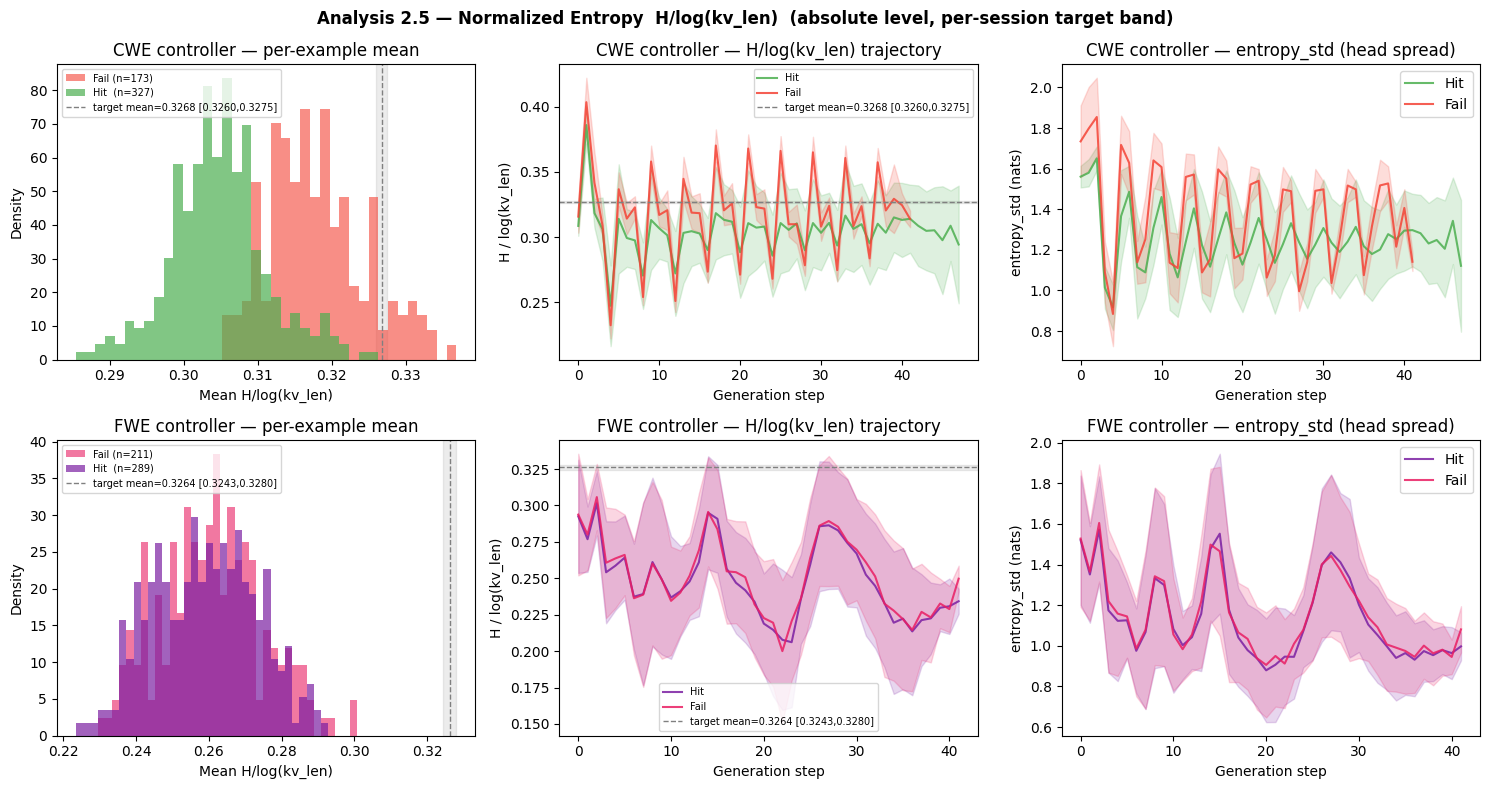

Normalized entropy summary (H/log kv_len):
                               mean_Hn   vs_tgt_mean      n             tgt_range
  CWE controller hit            0.3047       -0.0221    327       [0.3260,0.3275]
  CWE controller fail           0.3180       -0.0088    173       [0.3260,0.3275]
  FWE controller hit            0.2550       -0.0714    289       [0.3243,0.3280]
  FWE controller fail           0.2567       -0.0697    211       [0.3243,0.3280]


In [41]:
_fwe_loaded = "fwe_cHn" in dir()

task_rows_25 = [
    ("CWE controller", ctrl_Hn, ctrl_S, ctrl_tgt, ctrl_hit,  ~ctrl_hit,
     C["ctrl_hit"], C["ctrl_miss"], steps),
]
if _fwe_loaded:
    _fwe_hit_full = fwe_cs == 1.0
    task_rows_25.append((
        "FWE controller", fwe_cHn, fwe_cS, fwe_ctgt, _fwe_hit_full, ~_fwe_hit_full,
        "#7B1FA2", "#E91E63", fwe_steps,
    ))
else:
    print("⚠  FWE not loaded — only CWE row shown. Run the FWE loading cell (69e1ec41) first.")

n_rows = len(task_rows_25)
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
if n_rows == 1:
    axes = axes[None, :]
fig.suptitle("Analysis 2.5 — Normalized Entropy  H/log(kv_len)  (absolute level, per-session target band)",
             fontsize=12, fontweight="bold")

for row_i, (label, Hn, Std, tgt, hit, miss, c_hit, c_miss, st) in enumerate(task_rows_25):
    n_hit, n_miss = hit.sum(), miss.sum()

    # -- per-example mean Hn histogram --
    ax = axes[row_i, 0]
    hit_means  = np.nanmean(Hn[hit],  axis=1)
    miss_means = np.nanmean(Hn[miss], axis=1)
    all_vals = np.concatenate([hit_means, miss_means])
    bins = np.linspace(all_vals.min(), all_vals.max(), 40)
    ax.hist(miss_means, bins=bins, alpha=0.6, color=c_miss, density=True, label=f"Fail (n={n_miss})")
    ax.hist(hit_means,  bins=bins, alpha=0.7, color=c_hit,  density=True, label=f"Hit  (n={n_hit})")
    draw_target_band(ax, tgt, orient="v")
    ax.set_title(f"{label} — per-example mean")
    ax.set_xlabel("Mean H/log(kv_len)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

    # -- Hn trajectory --
    ax = axes[row_i, 1]
    for mask, lbl, col in [(hit, "Hit", c_hit), (miss, "Fail", c_miss)]:
        m = np.nanmean(Hn[mask], axis=0)
        s = np.nanstd(Hn[mask],  axis=0)
        ax.plot(st, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(st, m-s, m+s, color=col, alpha=BAND)
    draw_target_band(ax, tgt, orient="h")
    ax.set_title(f"{label} — H/log(kv_len) trajectory")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("H / log(kv_len)")
    ax.legend(fontsize=7)

    # -- entropy_std trajectory (head spread) --
    ax = axes[row_i, 2]
    for mask, lbl, col in [(hit, "Hit", c_hit), (miss, "Fail", c_miss)]:
        m = np.nanmean(Std[mask], axis=0)
        s = np.nanstd(Std[mask],  axis=0)
        ax.plot(st, m, color=col, label=lbl, alpha=0.85)
        ax.fill_between(st, m-s, m+s, color=col, alpha=BAND)
    ax.set_title(f"{label} — entropy_std (head spread)")
    ax.set_xlabel("Generation step")
    ax.set_ylabel("entropy_std (nats)")
    ax.legend()

fig.tight_layout()
plt.show()

print("Normalized entropy summary (H/log kv_len):")
print(f"  {chr(32)*25}  {'mean_Hn':>9}  {'vs_tgt_mean':>12}  {'n':>5}  {'tgt_range':>20}")
for label, Hn, _, tgt, hit, miss, *_ in task_rows_25:
    tgt_rng = f"[{tgt.min():.4f},{tgt.max():.4f}]"
    for mask, lbl in [(hit, "hit"), (miss, "fail")]:
        mn = float(np.nanmean(Hn[mask]))
        key = label + " " + lbl
        print(f"  {key:<25}  {mn:>9.4f}  {mn-tgt.mean():>+12.4f}  {mask.sum():>5}  {tgt_rng:>20}")


## Analysis 10 — Matched-example comparison

Groups based on correctness of **both** runs on the same example:
- **ctrl-only hit** (controller right, baseline wrong) — the interesting gain
- **both hit** — examples both can do
- **both miss** — hard examples neither can crack
- **base-only hit** — regressions (rare)

Seven panels:
1. Controller entropy trajectory by group
2. Baseline entropy trajectory, same grouping (shows what the baseline sees on those same examples)
3. Entropy delta (ctrl − baseline per example): what changed for the ctrl-only hits?
4. Controller tracking error by group
5. Baseline tracking error by group
6. Controller temperature trajectory by group
7. Step-0 entropy distribution by group — was it already predictable at the first token?

/tmp/ipykernel_2202411/3372342111.py:22: RuntimeWarning: Mean of empty slice
  m = np.nanmean(H[mask], axis=0)
/tmp/ipykernel_2202411/3372342111.py:52: RuntimeWarning: Mean of empty slice
  diff = np.nanmean(ctrl_Hn[mask] - base_Hn[mask], axis=0)
/tmp/ipykernel_2202411/3372342111.py:75: RuntimeWarning: Mean of empty slice
  m = np.nanmean(ctrl_T[mask], axis=0)
/tmp/ipykernel_2202411/3372342111.py:89: RuntimeWarning: Mean of empty slice
  m = np.nanmean(ctrl_S[mask], axis=0)


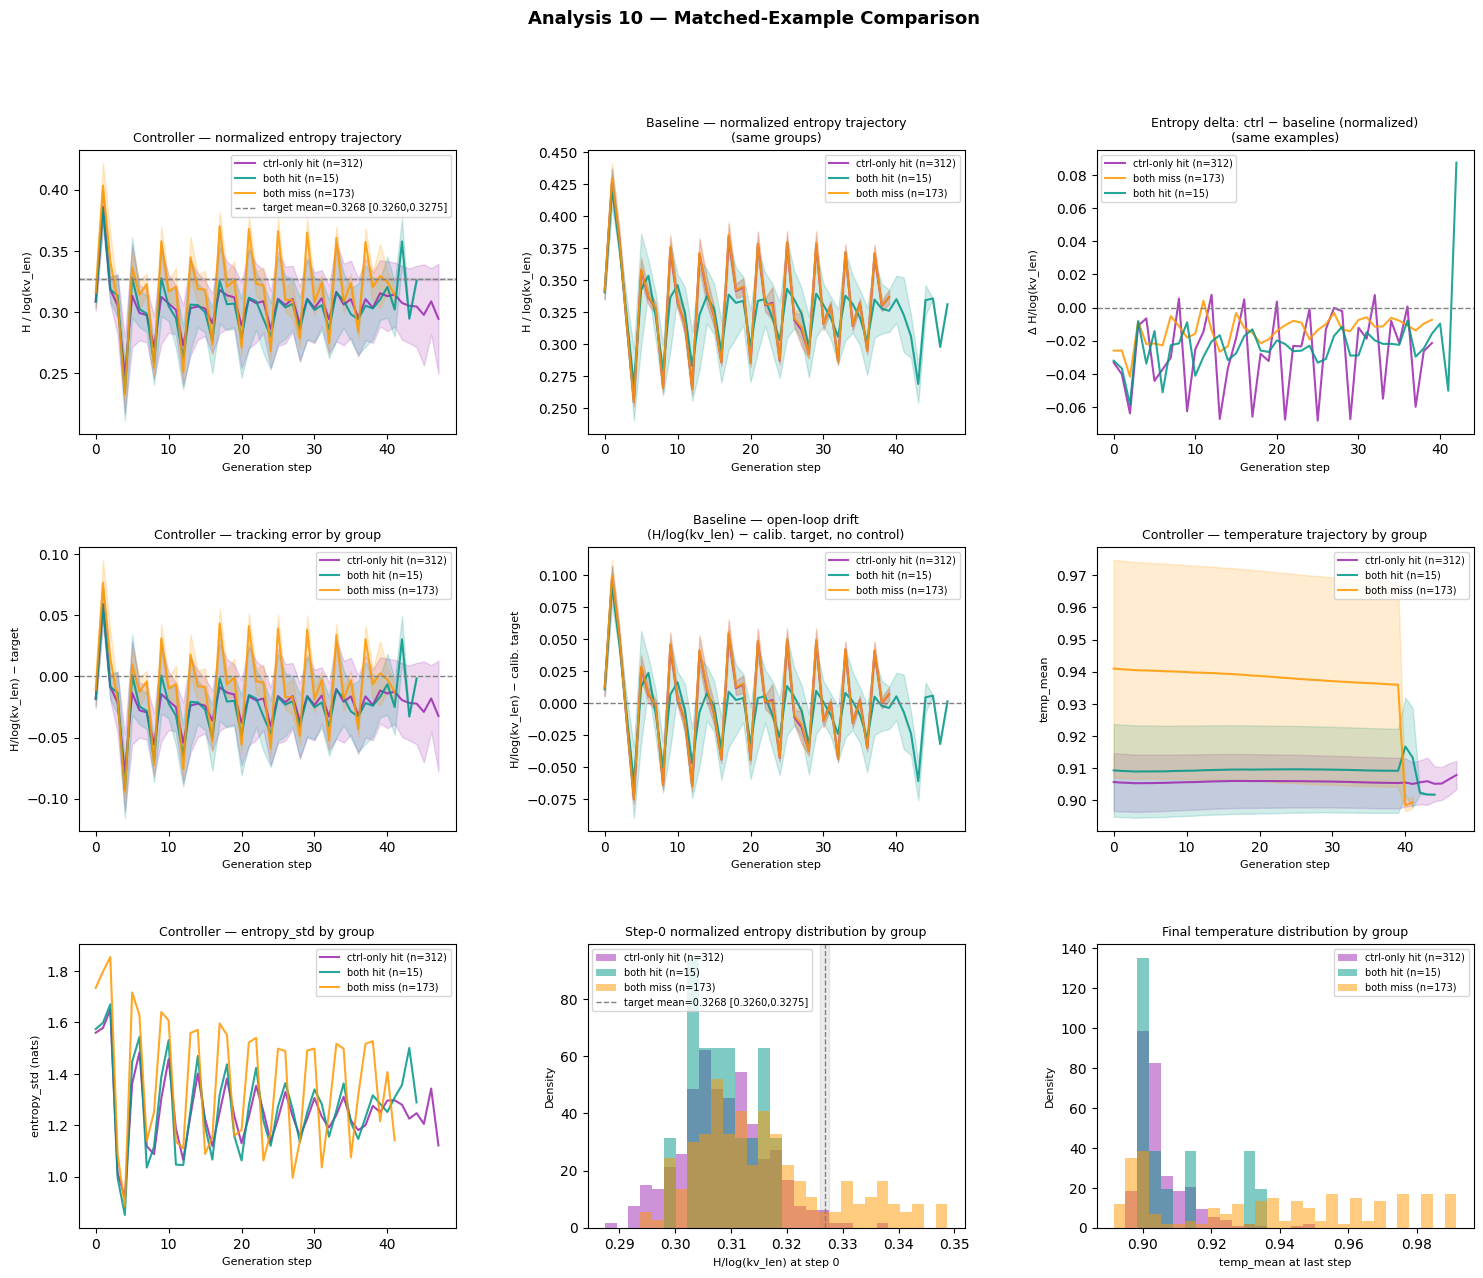

Group summary stats (ctrl_Hn/base_Hn = normalized entropy; ctrl_err/base_err = H/log(kv_len)−target):
group                  n  ctrl_score  base_score  ctrl_Hn  base_Hn   ctrl_err   base_err  ctrl_T_fin
----------------------------------------------------------------------------------------------------
ctrl-only hit        312       41.8%        0.0%   0.3048   0.3314    -0.0220    +0.0015      0.9054
both hit              15       35.3%       23.3%   0.3025   0.3265    -0.0244    -0.0034      0.9092
both miss            173        0.0%        0.0%   0.3180   0.3319    -0.0088    +0.0020      0.9360


In [35]:
GC = {
    "ctrl_only": "#9C27B0",
    "both_hit":  "#009688",
    "both_miss": "#FF9800",
    "base_only": "#2196F3",
}
groups = [
    (ctrl_only, "ctrl-only hit",  GC["ctrl_only"]),
    (both_hit,  "both hit",       GC["both_hit"]),
    (both_miss, "both miss",      GC["both_miss"]),
    (base_only, "base-only hit",  GC["base_only"]),
]

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Analysis 10 — Matched-Example Comparison", fontsize=13, fontweight="bold")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

def plot_traj(ax, H, tgt, title, ylabel, show_target=False, show_zero=False):
    for mask, lbl, col in groups:
        if mask.sum() == 0:
            continue
        m = np.nanmean(H[mask], axis=0)
        s = np.nanstd(H[mask],  axis=0)
        ax.plot(steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
        ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
    if show_target:
        draw_target_band(ax, tgt, orient="h")
    if show_zero:
        ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("Generation step", fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.legend(fontsize=7)

# (0,0) Controller normalized entropy — show per-session target band
ax = fig.add_subplot(gs[0, 0])
plot_traj(ax, ctrl_Hn, ctrl_tgt, "Controller — normalized entropy trajectory",
          "H / log(kv_len)", show_target=True)

# (0,1) Baseline normalized entropy — no target (baseline has none)
ax = fig.add_subplot(gs[0, 1])
plot_traj(ax, base_Hn, base_tgt, "Baseline — normalized entropy trajectory\n(same groups)",
          "H / log(kv_len)", show_target=False)

# (0,2) Entropy delta: ctrl_Hn - base_Hn per group
ax = fig.add_subplot(gs[0, 2])
for mask, lbl, col in [(ctrl_only, "ctrl-only hit", GC["ctrl_only"]),
                        (both_miss, "both miss",     GC["both_miss"]),
                        (both_hit,  "both hit",      GC["both_hit"])]:
    if mask.sum() == 0:
        continue
    diff = np.nanmean(ctrl_Hn[mask] - base_Hn[mask], axis=0)
    ax.plot(steps, diff, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_title("Entropy delta: ctrl − baseline (normalized)\n(same examples)", fontsize=9)
ax.set_xlabel("Generation step", fontsize=8)
ax.set_ylabel("Δ H/log(kv_len)", fontsize=8)
ax.legend(fontsize=7)

# (1,0) Controller tracking error by group
ax = fig.add_subplot(gs[1, 0])
plot_traj(ax, ctrl_err, ctrl_tgt, "Controller — tracking error by group",
          "H/log(kv_len) − target", show_zero=True)

# (1,1) Baseline open-loop drift (not tracking error)
ax = fig.add_subplot(gs[1, 1])
plot_traj(ax, base_err, base_tgt, "Baseline — open-loop drift\n(H/log(kv_len) − calib. target, no control)",
          "H/log(kv_len) − calib. target", show_zero=True)

# (1,2) Controller temperature trajectory by group
ax = fig.add_subplot(gs[1, 2])
for mask, lbl, col in groups:
    if mask.sum() == 0:
        continue
    m = np.nanmean(ctrl_T[mask], axis=0)
    s = np.nanstd(ctrl_T[mask],  axis=0)
    ax.plot(steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
    ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
ax.set_title("Controller — temperature trajectory by group", fontsize=9)
ax.set_xlabel("Generation step", fontsize=8)
ax.set_ylabel("temp_mean", fontsize=8)
ax.legend(fontsize=7)

# (2,0) entropy_std by group — controller (raw nats)
ax = fig.add_subplot(gs[2, 0])
for mask, lbl, col in groups:
    if mask.sum() == 0:
        continue
    m = np.nanmean(ctrl_S[mask], axis=0)
    ax.plot(steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
ax.set_title("Controller — entropy_std by group", fontsize=9)
ax.set_xlabel("Generation step", fontsize=8)
ax.set_ylabel("entropy_std (nats)", fontsize=8)
ax.legend(fontsize=7)

# (2,1) Step-0 normalized entropy distribution — with per-session target band
ax = fig.add_subplot(gs[2, 1])
all_s0 = np.concatenate([ctrl_Hn[m, 0] for m, _, _ in groups
                          if m.sum() > 0 and not np.all(np.isnan(ctrl_Hn[m, 0]))])
bins = np.linspace(np.nanmin(all_s0), np.nanmax(all_s0), 30)
for mask, lbl, col in groups:
    if mask.sum() == 0:
        continue
    ax.hist(ctrl_Hn[mask, 0], bins=bins, alpha=0.5, color=col, density=True,
            label=f"{lbl} (n={mask.sum()})")
draw_target_band(ax, ctrl_tgt, orient="v")
ax.set_title("Step-0 normalized entropy distribution by group", fontsize=9)
ax.set_xlabel("H/log(kv_len) at step 0", fontsize=8)
ax.set_ylabel("Density", fontsize=8)
ax.legend(fontsize=7)

# (2,2) Final temperature distribution by group
ax = fig.add_subplot(gs[2, 2])
def last_valid(arr):
    out = np.full(arr.shape[0], np.nan)
    for i in range(arr.shape[0]):
        valid = np.where(~np.isnan(arr[i]))[0]
        if len(valid):
            out[i] = arr[i, valid[-1]]
    return out

ctrl_T_final = last_valid(ctrl_T)
all_ft = np.concatenate([ctrl_T_final[m] for m, _, _ in groups if m.sum() > 0])
bins = np.linspace(np.nanmin(all_ft), np.nanmax(all_ft), 30)
for mask, lbl, col in groups:
    if mask.sum() == 0:
        continue
    ax.hist(ctrl_T_final[mask], bins=bins, alpha=0.5, color=col, density=True,
            label=f"{lbl} (n={mask.sum()})")
ax.set_title("Final temperature distribution by group", fontsize=9)
ax.set_xlabel("temp_mean at last step", fontsize=8)
ax.set_ylabel("Density", fontsize=8)
ax.legend(fontsize=7)

plt.show()

print("Group summary stats (ctrl_Hn/base_Hn = normalized entropy; ctrl_err/base_err = H/log(kv_len)−target):")
header = (f"{'group':<18} {'n':>5} {'ctrl_score':>11} {'base_score':>11} "
          f"{'ctrl_Hn':>8} {'base_Hn':>8} {'ctrl_err':>10} {'base_err':>10} {'ctrl_T_fin':>11}")
print(header)
print("-" * len(header))
for mask, lbl, col in groups:
    if mask.sum() == 0:
        continue
    print(f"{lbl:<18} {mask.sum():>5} "
          f"{ctrl_score[mask].mean()*100:>10.1f}% {base_score[mask].mean()*100:>10.1f}% "
          f"{np.nanmean(ctrl_Hn[mask]):>8.4f} {np.nanmean(base_Hn[mask]):>8.4f} "
          f"{np.nanmean(ctrl_err[mask]):>+10.4f} {np.nanmean(base_err[mask]):>+10.4f} "
          f"{np.nanmean(ctrl_T_final[mask]):>11.4f}")

---
## FWE 32k — Controller vs Baseline

**FWE baseline**: `ruler_all_acc = 86.0%`  |  **FWE controller**: `ruler_all_acc = 84.8%` → slight regression  
FWE = find the 3 most frequent *fake* (out-of-vocabulary) words in a coded 32k text.

Same controller hyperparameters as CWE. Questions:
- Where does the regression come from?
- Why does the same controller help CWE but hurt FWE?
- What does this tell us about the mechanism?

In [36]:
FWE_ROOT = Path("/c2/jenny/r3/RULER_outputs/llama3.1-8b-chat/synthetic/32768/data_session_runs/fwe")
FWE_BASE_TAG = "entropy_attn_fwe_cwe_32k_baseline.jsonl"
FWE_CTRL_TAG = "50session_3cali_prefixON_0p7ema.jsonl"

fwe_bp = load_jsonl(FWE_ROOT / f"fwe_entropy_attn_predictions_{FWE_BASE_TAG}")
fwe_cp = load_jsonl(FWE_ROOT / f"fwe_entropy_attn_predictions_{FWE_CTRL_TAG}")
fwe_be = load_jsonl(FWE_ROOT / f"fwe_entropy_attn_entropy_log_{FWE_BASE_TAG}")
fwe_ce = load_jsonl(FWE_ROOT / f"fwe_entropy_attn_entropy_log_{FWE_CTRL_TAG}")

FWE_STEPS = min(
    max(s["step"] for ex in fwe_be for s in ex["entropy_log"]) + 1,
    max(s["step"] for ex in fwe_ce for s in ex["entropy_log"]) + 1,
)
fwe_steps = np.arange(FWE_STEPS)

fwe_bH, fwe_bS, fwe_bT, fwe_bKV, fwe_btgt = to_arrays(fwe_be, FWE_STEPS)
fwe_cH, fwe_cS, fwe_cT, fwe_cKV, fwe_ctgt = to_arrays(fwe_ce, FWE_STEPS)

# Normalized entropy: H / log(kv_len) — same scale as MRCR attn_entropy_trace
fwe_bHn = fwe_bH / np.log(np.where(np.isnan(fwe_bKV), np.nan, fwe_bKV))
fwe_cHn = fwe_cH / np.log(np.where(np.isnan(fwe_cKV), np.nan, fwe_cKV))

fwe_bs = np.array([p["_ruler_all_hit"] for p in fwe_bp])
fwe_cs = np.array([p["_ruler_all_hit"] for p in fwe_cp])

# Regression groups (score-level, not just binary)
fwe_ctrl_better = fwe_cs > fwe_bs
fwe_ctrl_worse  = fwe_cs < fwe_bs
fwe_tied        = fwe_cs == fwe_bs

# Generation lengths
fwe_b_lens = (~np.isnan(fwe_bH)).sum(axis=1)
fwe_c_lens = (~np.isnan(fwe_cH)).sum(axis=1)

print(f"FWE base  ruler_all_acc: {fwe_bs.mean()*100:.2f}%")
print(f"FWE ctrl  ruler_all_acc: {fwe_cs.mean()*100:.2f}%")
print(f"\nRegression groups: ctrl_better={fwe_ctrl_better.sum()}  ctrl_worse={fwe_ctrl_worse.sum()}  tied={fwe_tied.sum()}")
print(f"\nMean gen length — base: {fwe_b_lens.mean():.1f}  ctrl: {fwe_c_lens.mean():.1f}")
print(f"  ctrl_worse  — base: {fwe_b_lens[fwe_ctrl_worse].mean():.1f}  ctrl: {fwe_c_lens[fwe_ctrl_worse].mean():.1f}")
print(f"  ctrl_better — base: {fwe_b_lens[fwe_ctrl_better].mean():.1f}  ctrl: {fwe_c_lens[fwe_ctrl_better].mean():.1f}")
print(f"\nScore transitions (base→ctrl):")
from collections import Counter
trans = Counter((round(b,2), round(c,2)) for b,c in zip(fwe_bs, fwe_cs))
for (b, c), n in sorted(trans.items()):
    delta = "↑" if c > b else ("↓" if c < b else "=")
    print(f"  {b:.2f} → {c:.2f}  {delta}  n={n}")

FWE base  ruler_all_acc: 86.00%
FWE ctrl  ruler_all_acc: 84.80%

Regression groups: ctrl_better=37  ctrl_worse=54  tied=409

Mean gen length — base: 38.0  ctrl: 25.1
  ctrl_worse  — base: 38.1  ctrl: 24.1
  ctrl_better — base: 37.9  ctrl: 21.6

Score transitions (base→ctrl):
  0.33 → 0.33  =  n=8
  0.33 → 0.67  ↑  n=3
  0.67 → 0.33  ↓  n=8
  0.67 → 0.67  =  n=146
  0.67 → 1.00  ↑  n=34
  1.00 → 0.33  ↓  n=1
  1.00 → 0.67  ↓  n=45
  1.00 → 1.00  =  n=255


### FWE — Where does the regression come from?

The regression is specifically about **rank-3 word selection**: both systems always get at least one word right (`contains_acc=100%` for both). The controller shifts format from verbose ("word (appears N times)") to concise ("word1, word2, and word3"), generating **~25 steps instead of ~38**. This is not truncation — it's a complete, valid output. The regression and improvement both come from the 3rd word: the model gets top-2 correct reliably, and sharpened attention changes which rank-3 candidate wins.

/tmp/ipykernel_2202411/4123785777.py:56: RuntimeWarning: Mean of empty slice
  m = np.nanmean(fwe_cHn[mask], axis=0)
/c2/jenny/miniconda3/envs/ruler/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_2202411/4123785777.py:69: RuntimeWarning: Mean of empty slice
  m = np.nanmean(fwe_bHn[mask], axis=0)
/tmp/ipykernel_2202411/4123785777.py:81: RuntimeWarning: Mean of empty slice
  m = np.nanmean(fwe_cT[mask], axis=0)


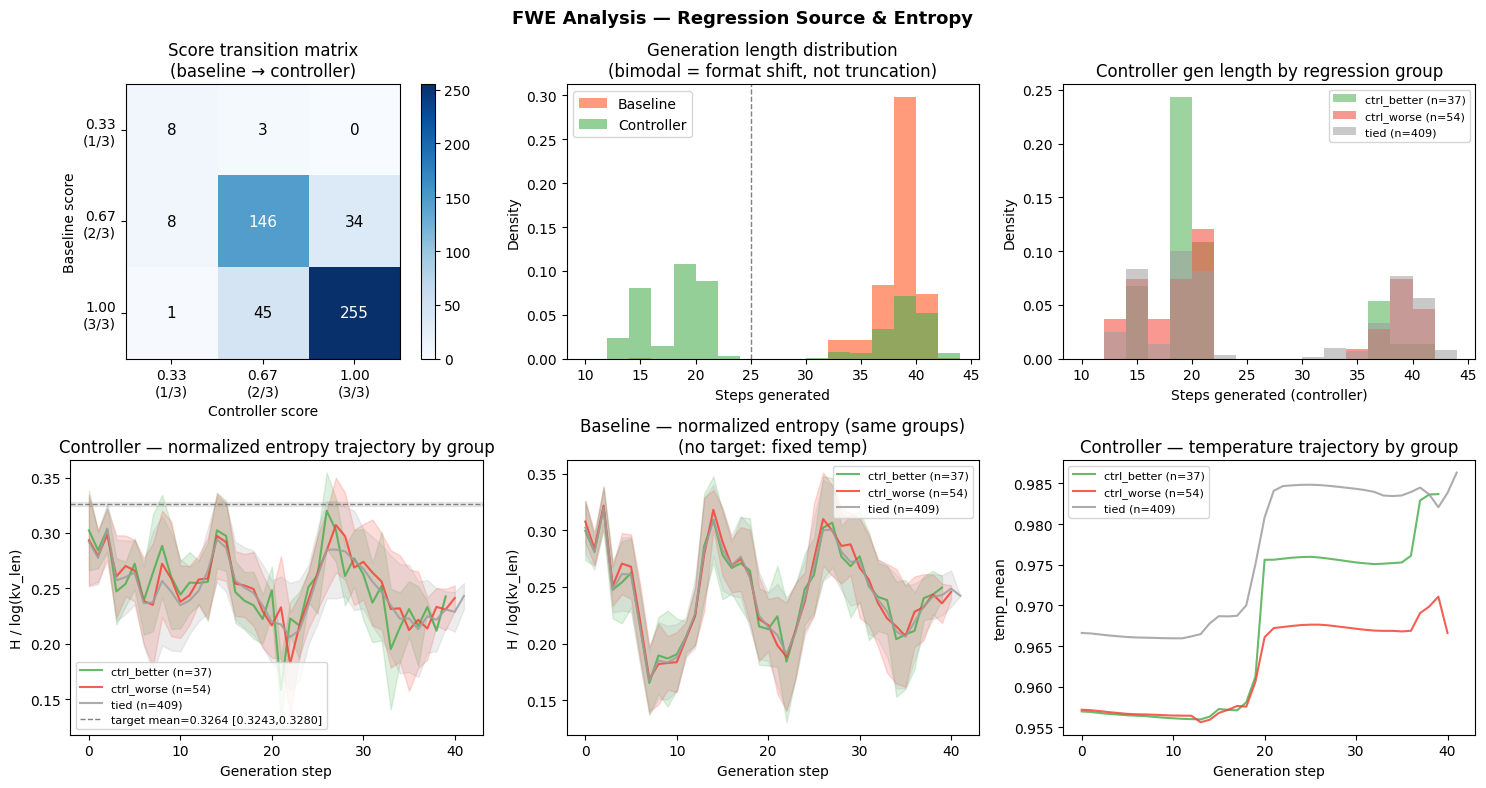

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("FWE Analysis — Regression Source & Entropy", fontsize=13, fontweight="bold")

FG = {"better": "#4CAF50", "worse": "#F44336", "tied": "#9E9E9E"}
fwe_groups = [
    (fwe_ctrl_better, "ctrl_better", FG["better"]),
    (fwe_ctrl_worse,  "ctrl_worse",  FG["worse"]),
    (fwe_tied,        "tied",        FG["tied"]),
]

# (0,0) Score transition heatmap
ax = axes[0, 0]
score_vals = [0.33, 0.67, 1.0]
mat = np.zeros((3, 3), dtype=int)
for bi, bv in enumerate(score_vals):
    for ci, cv in enumerate(score_vals):
        mat[bi, ci] = np.sum(np.isclose(fwe_bs, bv, atol=0.02) & np.isclose(fwe_cs, cv, atol=0.02))
im = ax.imshow(mat, cmap="Blues")
ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
ax.set_xticklabels(["0.33\n(1/3)", "0.67\n(2/3)", "1.00\n(3/3)"])
ax.set_yticklabels(["0.33\n(1/3)", "0.67\n(2/3)", "1.00\n(3/3)"])
ax.set_xlabel("Controller score"); ax.set_ylabel("Baseline score")
ax.set_title("Score transition matrix\n(baseline → controller)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(mat[i,j]), ha="center", va="center",
                color="white" if mat[i,j] > 100 else "black", fontsize=11)
plt.colorbar(im, ax=ax)

# (0,1) Generation length distribution
ax = axes[0, 1]
bins = np.arange(10, 45, 2)
ax.hist(fwe_b_lens, bins=bins, alpha=0.6, color="#FF5722", density=True, label="Baseline")
ax.hist(fwe_c_lens, bins=bins, alpha=0.6, color="#4CAF50", density=True, label="Controller")
ax.set_title("Generation length distribution\n(bimodal = format shift, not truncation)")
ax.set_xlabel("Steps generated")
ax.set_ylabel("Density")
ax.legend()
ax.axvline(25, color="gray", ls="--", lw=1)

# (0,2) Gen length by regression group (controller)
ax = axes[0, 2]
for mask, lbl, col in fwe_groups:
    if mask.sum() == 0: continue
    ax.hist(fwe_c_lens[mask], bins=bins, alpha=0.55, color=col, density=True,
            label=f"{lbl} (n={mask.sum()})")
ax.set_title("Controller gen length by regression group")
ax.set_xlabel("Steps generated (controller)")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

# (1,0) Controller — normalized entropy by group + per-session target band
ax = axes[1, 0]
for mask, lbl, col in fwe_groups:
    if mask.sum() == 0: continue
    m = np.nanmean(fwe_cHn[mask], axis=0)
    s = np.nanstd(fwe_cHn[mask],  axis=0)
    ax.plot(fwe_steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
    ax.fill_between(fwe_steps, m-s, m+s, color=col, alpha=BAND)
draw_target_band(ax, fwe_ctgt, orient="h")
ax.set_title("Controller — normalized entropy trajectory by group")
ax.set_xlabel("Generation step"); ax.set_ylabel("H / log(kv_len)")
ax.legend(fontsize=8)

# (1,1) Baseline — normalized entropy by group (no target — baseline has none)
ax = axes[1, 1]
for mask, lbl, col in fwe_groups:
    if mask.sum() == 0: continue
    m = np.nanmean(fwe_bHn[mask], axis=0)
    s = np.nanstd(fwe_bHn[mask],  axis=0)
    ax.plot(fwe_steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
    ax.fill_between(fwe_steps, m-s, m+s, color=col, alpha=BAND)
ax.set_title("Baseline — normalized entropy (same groups)\n(no target: fixed temp)")
ax.set_xlabel("Generation step"); ax.set_ylabel("H / log(kv_len)")
ax.legend(fontsize=8)

# (1,2) Temperature trajectory by group — controller
ax = axes[1, 2]
for mask, lbl, col in fwe_groups:
    if mask.sum() == 0: continue
    m = np.nanmean(fwe_cT[mask], axis=0)
    ax.plot(fwe_steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
ax.set_title("Controller — temperature trajectory by group")
ax.set_xlabel("Generation step"); ax.set_ylabel("temp_mean")
ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

---
## Cross-task comparison — CWE vs FWE: the core mechanism

**Hypothesis**: The controller's benefit scales with the gap between the model's *natural* baseline entropy and the optimal (retrieval-focused) entropy. If baseline entropy is already low, the controller adds noise; if it's high, the controller corrects a genuine deficit.

/tmp/ipykernel_2202411/2272230459.py:80: RuntimeWarning: Mean of empty slice
  cwe_miss_H = np.nanmean(ctrl_H[~ctrl_hit], axis=0)[:SHARED]
/tmp/ipykernel_2202411/2272230459.py:81: RuntimeWarning: Mean of empty slice
  fwe_worse_H = np.nanmean(fwe_cH[fwe_ctrl_worse], axis=0)[:SHARED]
/tmp/ipykernel_2202411/2272230459.py:82: RuntimeWarning: Mean of empty slice
  fwe_better_H = np.nanmean(fwe_cH[fwe_ctrl_better], axis=0)[:SHARED]


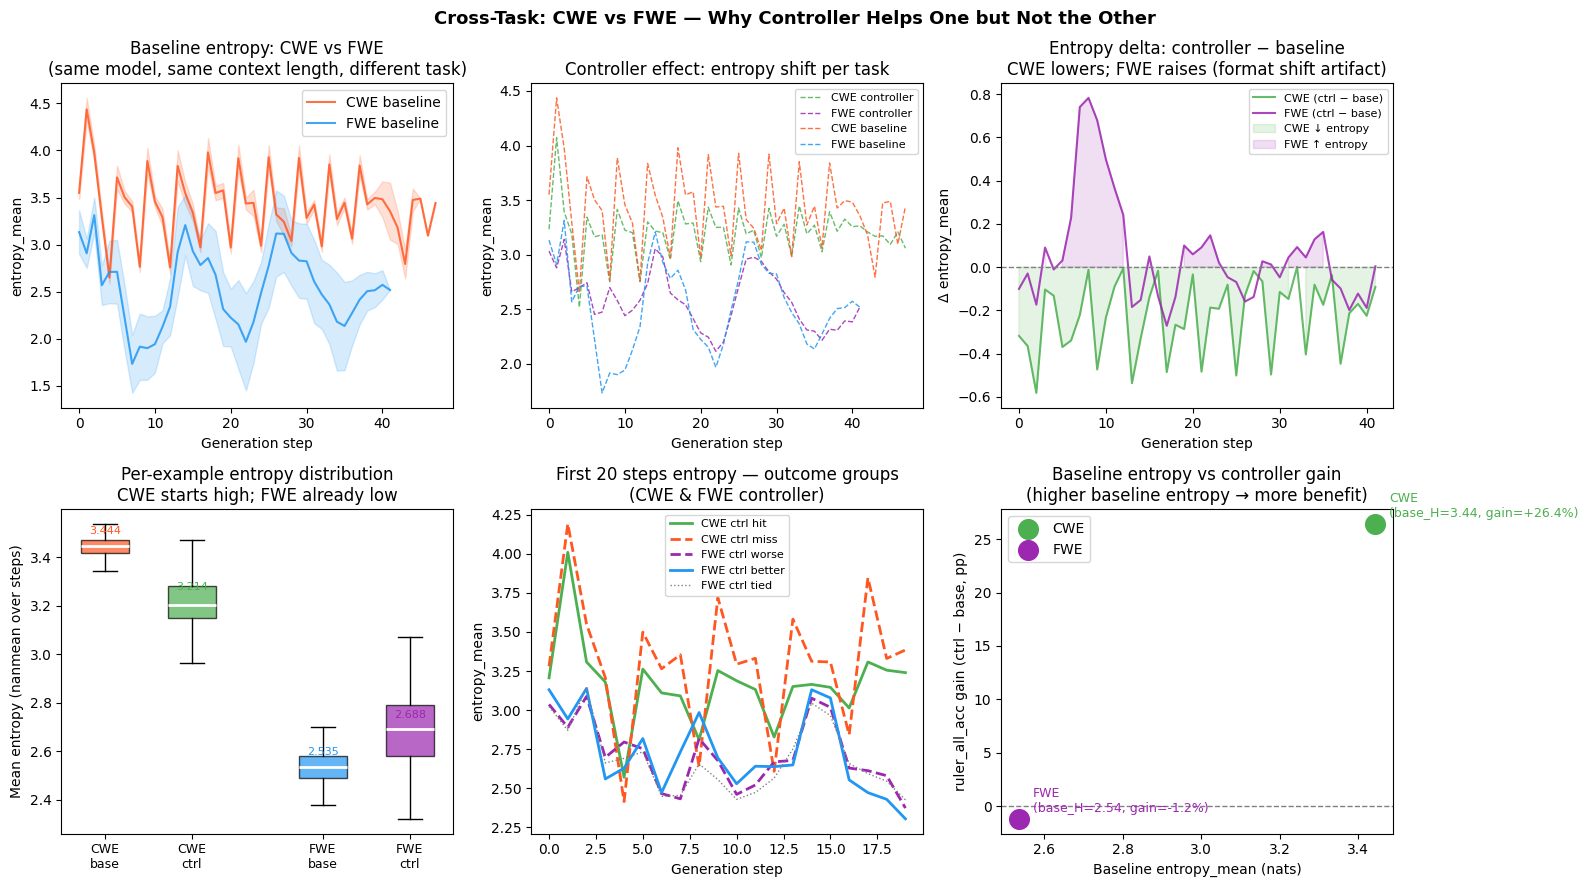

Cross-task entropy summary:
                         base_H     ctrl_H      Δ_H   ruler_all gain
CWE                      3.4440     3.2124  -0.2315          +26.44pp
FWE                      2.5353     2.6465  +0.1112           -1.20pp


In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Cross-Task: CWE vs FWE — Why Controller Helps One but Not the Other",
             fontsize=13, fontweight="bold")

TC = {"cwe_base": "#FF5722", "cwe_ctrl": "#4CAF50",
      "fwe_base": "#2196F3", "fwe_ctrl": "#9C27B0"}

# -- (0,0) Baseline entropy trajectory: CWE vs FWE --
ax = axes[0, 0]
for H, steps_, lbl, col in [
    (base_H,  steps,     "CWE baseline", TC["cwe_base"]),
    (fwe_bH,  fwe_steps, "FWE baseline", TC["fwe_base"]),
]:
    m = np.nanmean(H, axis=0)
    s = np.nanstd(H,  axis=0)
    ax.plot(steps_, m, color=col, label=lbl, alpha=0.85)
    ax.fill_between(steps_, m-s, m+s, color=col, alpha=BAND)
ax.set_title("Baseline entropy: CWE vs FWE\n(same model, same context length, different task)")
ax.set_xlabel("Generation step"); ax.set_ylabel("entropy_mean")
ax.legend()

# -- (0,1) Controller entropy trajectory: CWE vs FWE --
ax = axes[0, 1]
for H, steps_, lbl, col in [
    (ctrl_H,  steps,     "CWE controller", TC["cwe_ctrl"]),
    (fwe_cH,  fwe_steps, "FWE controller", TC["fwe_ctrl"]),
    (base_H,  steps,     "CWE baseline",   TC["cwe_base"]),
    (fwe_bH,  fwe_steps, "FWE baseline",   TC["fwe_base"]),
]:
    m = np.nanmean(H, axis=0)
    ax.plot(steps_, m, color=col, label=lbl,
            alpha=0.85, ls="-" if "ctrl" in lbl else "--", lw=1.5 if "ctrl" in lbl else 1.0)
ax.set_title("Controller effect: entropy shift per task")
ax.set_xlabel("Generation step"); ax.set_ylabel("entropy_mean")
ax.legend(fontsize=8)

# -- (0,2) Entropy delta (ctrl - baseline) per task --
ax = axes[0, 2]
common = min(len(steps), len(fwe_steps))
cwe_delta = np.nanmean(ctrl_H, axis=0)[:common] - np.nanmean(base_H, axis=0)[:common]
fwe_delta = np.nanmean(fwe_cH, axis=0)[:common] - np.nanmean(fwe_bH, axis=0)[:common]
ax.plot(np.arange(common), cwe_delta, color=TC["cwe_ctrl"], label="CWE (ctrl − base)", alpha=0.85)
ax.plot(np.arange(common), fwe_delta, color=TC["fwe_ctrl"], label="FWE (ctrl − base)", alpha=0.85)
ax.axhline(0, color="gray", ls="--", lw=1)
ax.fill_between(np.arange(common), cwe_delta, 0,
                where=cwe_delta < 0, color=TC["cwe_ctrl"], alpha=0.15, label="CWE ↓ entropy")
ax.fill_between(np.arange(common), fwe_delta, 0,
                where=fwe_delta > 0, color=TC["fwe_ctrl"], alpha=0.15, label="FWE ↑ entropy")
ax.set_title("Entropy delta: controller − baseline\nCWE lowers; FWE raises (format shift artifact)")
ax.set_xlabel("Generation step"); ax.set_ylabel("Δ entropy_mean")
ax.legend(fontsize=8)

# -- (1,0) Per-example mean entropy: task × run --
ax = axes[1, 0]
task_data = [
    (np.nanmean(base_H,  axis=1), "CWE baseline",   TC["cwe_base"]),
    (np.nanmean(ctrl_H,  axis=1), "CWE controller", TC["cwe_ctrl"]),
    (np.nanmean(fwe_bH,  axis=1), "FWE baseline",   TC["fwe_base"]),
    (np.nanmean(fwe_cH,  axis=1), "FWE controller", TC["fwe_ctrl"]),
]
positions = [1, 2, 3.5, 4.5]
bp = ax.boxplot([d for d,_,_ in task_data], positions=positions, widths=0.55,
                patch_artist=True, showfliers=False,
                medianprops=dict(color="white", linewidth=2))
for patch, (_, lbl, col) in zip(bp["boxes"], task_data):
    patch.set_facecolor(col); patch.set_alpha(0.7)
ax.set_xticks(positions)
ax.set_xticklabels(["CWE\nbase", "CWE\nctrl", "FWE\nbase", "FWE\nctrl"], fontsize=9)
ax.set_title("Per-example entropy distribution\nCWE starts high; FWE already low")
ax.set_ylabel("Mean entropy (nanmean over steps)")
# Annotate means
for (d, lbl, col), pos in zip(task_data, positions):
    ax.text(pos, np.nanmean(d) + 0.05, f"{np.nanmean(d):.3f}", ha="center", fontsize=8, color=col)

# -- (1,1) Entropy at each step: CWE success path vs FWE typical --
# Use only steps 0-20 (shared) and split by score group
ax = axes[1, 1]
SHARED = 20
cwe_hit_H = np.nanmean(ctrl_H[ctrl_hit], axis=0)[:SHARED]
cwe_miss_H = np.nanmean(ctrl_H[~ctrl_hit], axis=0)[:SHARED]
fwe_worse_H = np.nanmean(fwe_cH[fwe_ctrl_worse], axis=0)[:SHARED]
fwe_better_H = np.nanmean(fwe_cH[fwe_ctrl_better], axis=0)[:SHARED]
fwe_tied_H = np.nanmean(fwe_cH[fwe_tied], axis=0)[:SHARED]
xs = np.arange(SHARED)
ax.plot(xs, cwe_hit_H,    color=TC["cwe_ctrl"], lw=2, label="CWE ctrl hit")
ax.plot(xs, cwe_miss_H,   color=TC["cwe_base"], lw=2, ls="--", label="CWE ctrl miss")
ax.plot(xs, fwe_worse_H,  color=TC["fwe_ctrl"], lw=2, ls="--", label="FWE ctrl worse")
ax.plot(xs, fwe_better_H, color=TC["fwe_base"], lw=2, label="FWE ctrl better")
ax.plot(xs, fwe_tied_H,   color="gray", lw=1, ls=":", label="FWE ctrl tied")
ax.set_title("First 20 steps entropy — outcome groups\n(CWE & FWE controller)")
ax.set_xlabel("Generation step"); ax.set_ylabel("entropy_mean")
ax.legend(fontsize=8)

# -- (1,2) Summary: baseline entropy vs controller gain --
ax = axes[1, 2]
# Each task: (baseline mean entropy, ruler_all_acc gain)
task_summary = {
    "CWE": (np.nanmean(base_H), 27.14 - 0.70),   # ctrl - base ruler_all_acc
    "FWE": (np.nanmean(fwe_bH), 84.80 - 86.00),
}
colors_ts = {"CWE": TC["cwe_ctrl"], "FWE": TC["fwe_ctrl"]}
for task, (ent, gain) in task_summary.items():
    ax.scatter(ent, gain, s=200, color=colors_ts[task], zorder=5, label=task)
    ax.annotate(f"{task}\n(base_H={ent:.2f}, gain={gain:+.1f}%)",
                (ent, gain), textcoords="offset points", xytext=(10, 5), fontsize=9,
                color=colors_ts[task])
ax.axhline(0, color="gray", ls="--", lw=1)
ax.set_xlabel("Baseline entropy_mean (nats)")
ax.set_ylabel("ruler_all_acc gain (ctrl − base, pp)")
ax.set_title("Baseline entropy vs controller gain\n(higher baseline entropy → more benefit)")
ax.legend()

fig.tight_layout()
plt.show()

# Numerical summary
print("Cross-task entropy summary:")
print(f"{'':20s} {'base_H':>10} {'ctrl_H':>10} {'Δ_H':>8} {'ruler_all gain':>16}")
print(f"{'CWE':20s} {np.nanmean(base_H):>10.4f} {np.nanmean(ctrl_H):>10.4f} "
      f"{np.nanmean(ctrl_H)-np.nanmean(base_H):>+8.4f} {27.14-0.70:>+15.2f}pp")
print(f"{'FWE':20s} {np.nanmean(fwe_bH):>10.4f} {np.nanmean(fwe_cH):>10.4f} "
      f"{np.nanmean(fwe_cH)-np.nanmean(fwe_bH):>+8.4f} {84.80-86.00:>+15.2f}pp")

---
## Normalized attention entropy trace: H / log(kv_len)

Same quantity as MRCR's `attn_entropy_trace` — normalizes by context length so traces from different sequence positions are on the same scale (~0.0–1.0, with typical LM operation in 0.30–0.55).

**Reference levels:**
- **Controller target** ≈ 0.327 — `prompt_target_mean` (calibrated normalized entropy)
- **MRCR operating level** ≈ 0.46 — mean `attn_entropy_trace` on 16–32k retrieval task (success cases)

This lets us directly compare whether RULER's controller is pushing entropy up or down relative to MRCR, and whether the operating regimes make sense for each task type.

/tmp/ipykernel_2202411/1939668134.py:7: RuntimeWarning: Mean of empty slice
  m = np.nanmean(X, axis=0)
/c2/jenny/miniconda3/envs/ruler/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


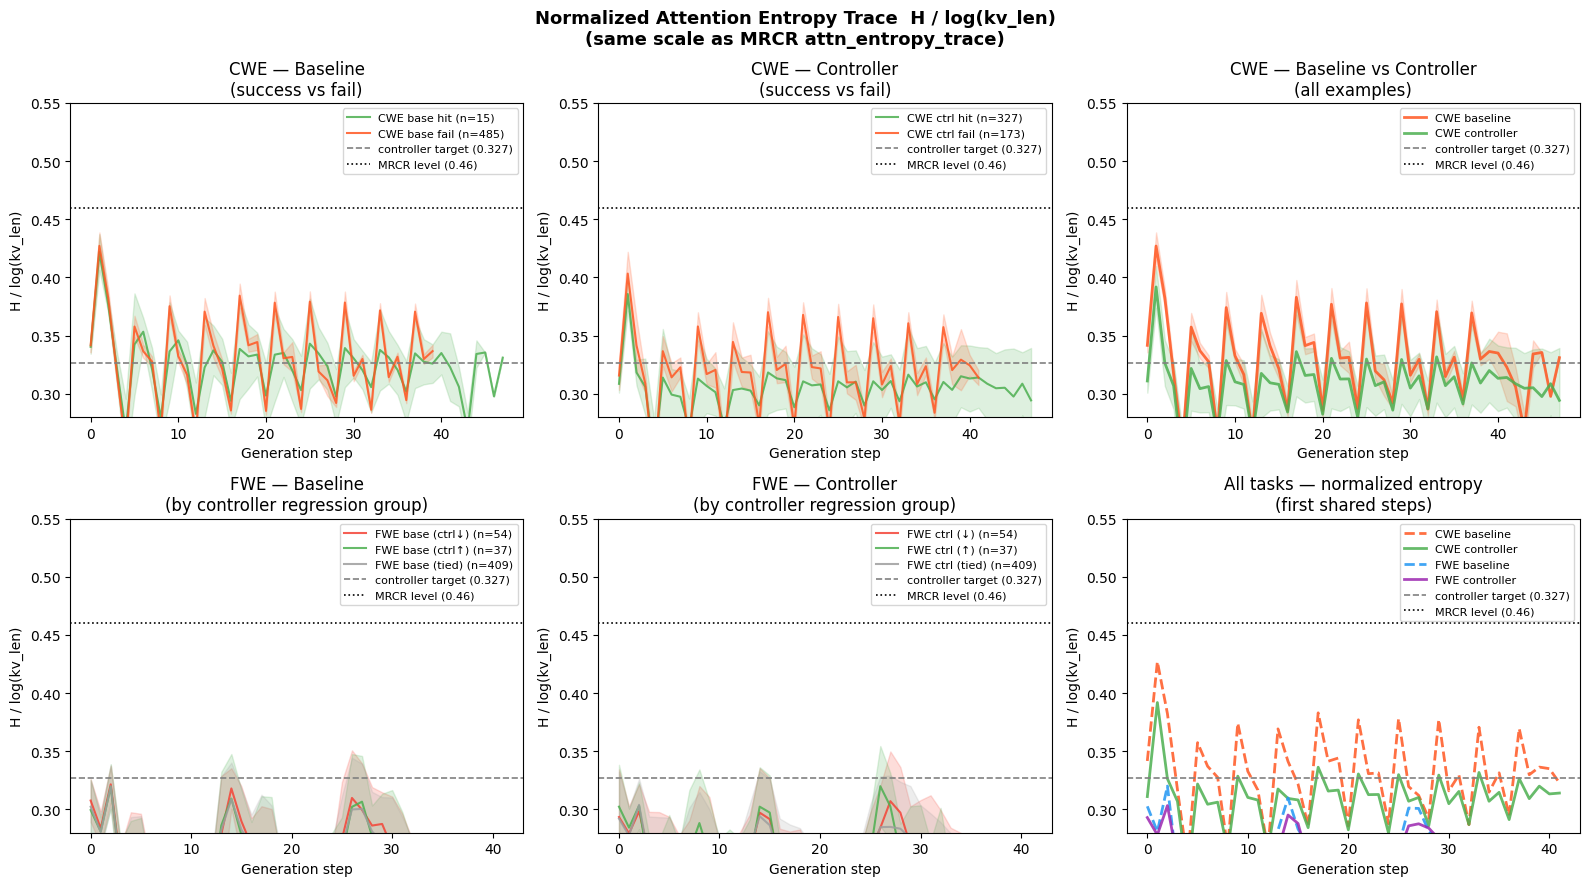

Normalized entropy summary (H / log kv_len):
                                 mean_Hn   vs target (0.327)   vs MRCR (0.46)
  CWE baseline                    0.3315             +0.0046          -0.1285
  CWE controller                  0.3092             -0.0177          -0.1508
  FWE baseline                    0.2450             -0.0819          -0.2150
  FWE controller                  0.2557             -0.0711          -0.2043


In [39]:
MRCR_LEVEL = 0.46   # mean attn_entropy_trace for MRCR success cases (16–32k)
CTRL_TGT_N = float(np.nanmean(ctrl_tgt))   # prompt_target_mean ≈ 0.327 (normalized)

# Helper: mean ± 1σ trace for a masked set of normalized-entropy arrays
def norm_trace(Hn, mask=None):
    X = Hn[mask] if mask is not None else Hn
    m = np.nanmean(X, axis=0)
    s = np.nanstd(X,  axis=0)
    return m, s

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Normalized Attention Entropy Trace  H / log(kv_len)\n"
             "(same scale as MRCR attn_entropy_trace)",
             fontsize=13, fontweight="bold")

TC2 = {"cwe_base": "#FF5722", "cwe_ctrl": "#4CAF50",
       "fwe_base": "#2196F3", "fwe_ctrl": "#9C27B0"}

def add_refs(ax):
    ax.axhline(CTRL_TGT_N, color="gray",   ls="--", lw=1.2, label=f"controller target ({CTRL_TGT_N:.3f})")
    ax.axhline(MRCR_LEVEL, color="black",  ls=":",  lw=1.2, label=f"MRCR level ({MRCR_LEVEL:.2f})")

# ── (0,0) CWE — baseline, success vs fail ────────────────────────────────────
ax = axes[0, 0]
for mask, lbl, col in [(base_hit, "CWE base hit", TC2["cwe_ctrl"]),
                        (~base_hit, "CWE base fail", TC2["cwe_base"])]:
    m, s = norm_trace(base_Hn, mask)
    ax.plot(steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
    ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
add_refs(ax)
ax.set_title("CWE — Baseline\n(success vs fail)")
ax.set_xlabel("Generation step")
ax.set_ylabel("H / log(kv_len)")
ax.legend(fontsize=8)
ax.set_ylim(0.28, 0.55)

# ── (0,1) CWE — controller, success vs fail ──────────────────────────────────
ax = axes[0, 1]
for mask, lbl, col in [(ctrl_hit, "CWE ctrl hit", TC2["cwe_ctrl"]),
                        (~ctrl_hit, "CWE ctrl fail", TC2["cwe_base"])]:
    m, s = norm_trace(ctrl_Hn, mask)
    ax.plot(steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
    ax.fill_between(steps, m-s, m+s, color=col, alpha=BAND)
add_refs(ax)
ax.set_title("CWE — Controller\n(success vs fail)")
ax.set_xlabel("Generation step")
ax.set_ylabel("H / log(kv_len)")
ax.legend(fontsize=8)
ax.set_ylim(0.28, 0.55)

# ── (0,2) CWE — baseline vs controller overlay ───────────────────────────────
ax = axes[0, 2]
for Hn, steps_, lbl, col in [
    (base_Hn, steps, "CWE baseline", TC2["cwe_base"]),
    (ctrl_Hn, steps, "CWE controller", TC2["cwe_ctrl"]),
]:
    m, s = norm_trace(Hn)
    ax.plot(steps_, m, color=col, label=lbl, alpha=0.85, lw=2)
    ax.fill_between(steps_, m-s, m+s, color=col, alpha=BAND)
add_refs(ax)
ax.set_title("CWE — Baseline vs Controller\n(all examples)")
ax.set_xlabel("Generation step")
ax.set_ylabel("H / log(kv_len)")
ax.legend(fontsize=8)
ax.set_ylim(0.28, 0.55)

# ── (1,0) FWE — baseline, regression groups ──────────────────────────────────
ax = axes[1, 0]
for mask, lbl, col in [(fwe_ctrl_worse,  "FWE base (ctrl↓)", "#F44336"),
                        (fwe_ctrl_better, "FWE base (ctrl↑)", "#4CAF50"),
                        (fwe_tied,        "FWE base (tied)",  "#9E9E9E")]:
    if mask.sum() == 0: continue
    m, s = norm_trace(fwe_bHn, mask)
    ax.plot(fwe_steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
    ax.fill_between(fwe_steps, m-s, m+s, color=col, alpha=BAND)
add_refs(ax)
ax.set_title("FWE — Baseline\n(by controller regression group)")
ax.set_xlabel("Generation step")
ax.set_ylabel("H / log(kv_len)")
ax.legend(fontsize=8)
ax.set_ylim(0.28, 0.55)

# ── (1,1) FWE — controller, regression groups ────────────────────────────────
ax = axes[1, 1]
for mask, lbl, col in [(fwe_ctrl_worse,  "FWE ctrl (↓)",  "#F44336"),
                        (fwe_ctrl_better, "FWE ctrl (↑)",  "#4CAF50"),
                        (fwe_tied,        "FWE ctrl (tied)","#9E9E9E")]:
    if mask.sum() == 0: continue
    m, s = norm_trace(fwe_cHn, mask)
    ax.plot(fwe_steps, m, color=col, label=f"{lbl} (n={mask.sum()})", alpha=0.85)
    ax.fill_between(fwe_steps, m-s, m+s, color=col, alpha=BAND)
add_refs(ax)
ax.set_title("FWE — Controller\n(by controller regression group)")
ax.set_xlabel("Generation step")
ax.set_ylabel("H / log(kv_len)")
ax.legend(fontsize=8)
ax.set_ylim(0.28, 0.55)

# ── (1,2) All four traces — CWE & FWE, base & ctrl ───────────────────────────
ax = axes[1, 2]
common = min(len(steps), len(fwe_steps))
xs = np.arange(common)
for Hn, steps_, lbl, col, ls in [
    (base_Hn, steps,     "CWE baseline",   TC2["cwe_base"],  "--"),
    (ctrl_Hn, steps,     "CWE controller", TC2["cwe_ctrl"],  "-"),
    (fwe_bHn, fwe_steps, "FWE baseline",   TC2["fwe_base"],  "--"),
    (fwe_cHn, fwe_steps, "FWE controller", TC2["fwe_ctrl"],  "-"),
]:
    m, _ = norm_trace(Hn)
    ax.plot(steps_[:common], m[:common], color=col, label=lbl, ls=ls, lw=2, alpha=0.85)
add_refs(ax)
ax.set_title("All tasks — normalized entropy\n(first shared steps)")
ax.set_xlabel("Generation step")
ax.set_ylabel("H / log(kv_len)")
ax.legend(fontsize=8)
ax.set_ylim(0.28, 0.55)

fig.tight_layout()
plt.show()

# Numerical summary
print("Normalized entropy summary (H / log kv_len):")
print(f"{'':30s} {'mean_Hn':>9} {'vs target (0.327)':>19} {'vs MRCR (0.46)':>16}")
for Hn, lbl in [(base_Hn,  "CWE baseline"),
                (ctrl_Hn,  "CWE controller"),
                (fwe_bHn,  "FWE baseline"),
                (fwe_cHn,  "FWE controller")]:
    mn = float(np.nanmean(Hn))
    print(f"  {lbl:<28} {mn:>9.4f}  {mn - CTRL_TGT_N:>+18.4f}  {mn - MRCR_LEVEL:>+15.4f}")